In [ ]:
%pip install pandas matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- File 1: Multi-station 2016-2020 (combined from individual year files) ---
files_2016_2020 = {
    '2016': '/content/AirQualityDataDaily_2016.csv',
    '2017': '/content/AirQualityDataDaily_2017.csv',
    '2018': '/content/AirQualityDataDaily_2018.csv',
    '2019': '/content/AirQualityDataDaily_2019.csv',
    '2020': '/content/AirQualityDataDaily_2020.csv'
}

all_records_2016_2020 = []
for year, file_path in files_2016_2020.items():
    # Read header for station names from each file
    header_row = pd.read_csv(file_path, skiprows=3, nrows=1, header=None)
    station_names = header_row.iloc[0].tolist()

    raw_year_df = pd.read_csv(file_path, skiprows=11, header=None)

    col_idx = 1
    station_idx = 1
    while col_idx < raw_year_df.shape[1] - 1:
        sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
        if pd.isna(sname) or str(sname).strip() == '':
            col_idx += 2; station_idx += 2; continue
        values = raw_year_df.iloc[:, col_idx]
        status = raw_year_df.iloc[:, col_idx + 1] if col_idx + 1 < raw_year_df.shape[1] else [None]*len(raw_year_df)
        for d, v, s in zip(raw_year_df.iloc[:, 0], values, status):
            all_records_2016_2020.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
        col_idx += 2; station_idx += 2

df1 = pd.DataFrame(all_records_2016_2020)


# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

print(f'Raw combined shape (before any parsing): {df.shape}')
df.head(10)

Raw combined shape (before any parsing): (10966, 4)


,date,station,pm25_raw,status_raw
0,2016-01-01,Auchencorth Moss,2.886,V ugm-3 (GRAV EMFAB)
1,2016-01-02,Auchencorth Moss,1.12,V ugm-3 (GRAV EMFAB)
2,2016-01-03,Auchencorth Moss,0.56,V ugm-3 (GRAV EMFAB)
3,2016-01-04,Auchencorth Moss,1.983,V ugm-3 (GRAV EMFAB)
4,2016-01-05,Auchencorth Moss,2.372,V ugm-3 (GRAV EMFAB)
5,2016-01-06,Auchencorth Moss,2.157,V ugm-3 (GRAV EMFAB)
6,2016-01-07,Auchencorth Moss,0.259,V ugm-3 (GRAV EMFAB)
7,2016-01-08,Auchencorth Moss,2.33,V ugm-3 (GRAV EMFAB)
8,2016-01-09,Auchencorth Moss,2.417,V ugm-3 (GRAV EMFAB)
9,2016-01-10,Auchencorth Moss,-0.086,V ugm-3 (GRAV EMFAB)


#### Standardize date columns

#### Timestamp normalization

In [3]:
#show the different date formats in the CSV's
print('Unique date formats in the raw CSVs:')
# Use one of the new 2016-2020 files for demonstration
raw_dates1 = pd.read_csv('/content/AirQualityDataDaily_2016.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
# Keep the 2021-2025 file path as is, assuming it exists
raw_dates2 = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv', skiprows=11, usecols=[0], header=None, nrows=1000)
unique_dates1 = raw_dates1[0].dropna().unique()
unique_dates2 = raw_dates2[0].dropna().unique()
print(f'File 1 (2016-2020 example) unique date formats: {unique_dates1}')
print(f'File 2 (2021-2025) unique date formats: {unique_dates2}')

Unique date formats in the raw CSVs:
File 1 (2016-2020 example) unique date formats: ['2016-01-01' '2016-01-02' '2016-01-03' '2016-01-04' '2016-01-05'
 '2016-01-06' '2016-01-07' '2016-01-08' '2016-01-09' '2016-01-10'
 '2016-01-11' '2016-01-12' '2016-01-13' '2016-01-14' '2016-01-15'
 '2016-01-16' '2016-01-17' '2016-01-18' '2016-01-19' '2016-01-20'
 '2016-01-21' '2016-01-22' '2016-01-23' '2016-01-24' '2016-01-25'
 '2016-01-26' '2016-01-27' '2016-01-28' '2016-01-29' '2016-01-30'
 '2016-01-31' '2016-02-01' '2016-02-02' '2016-02-03' '2016-02-04'
 '2016-02-05' '2016-02-06' '2016-02-07' '2016-02-08' '2016-02-09'
 '2016-02-10' '2016-02-11' '2016-02-12' '2016-02-13' '2016-02-14'
 '2016-02-15' '2016-02-16' '2016-02-17' '2016-02-18' '2016-02-19'
 '2016-02-20' '2016-02-21' '2016-02-22' '2016-02-23' '2016-02-24'
 '2016-02-25' '2016-02-26' '2016-02-27' '2016-02-28' '2016-02-29'
 '2016-03-01' '2016-03-02' '2016-03-03' '2016-03-04' '2016-03-05'
 '2016-03-06' '2016-03-07' '2016-03-08' '2016-03-09' '201

There are various date formats in the raw CSVs, so we need to normalize them to a consistent format. This will help with data analysis and ensure that all timestamps are comparable,

This will help during our time series modeling, as we can ensure that all timestamps are in a consistent format and can be easily compared across different stations and time periods. We can sort, resample, detect gaps, and perform other time-based operations more easily with a standardized timestamp format.

In [8]:
# Parse the 'date' column to datetime and normalize to midnight so the
# series is strictly day-resolution (any stray time-of-day is dropped).
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()
print(f'After parsing + normalizing dates, shape: {df.shape}')
print(df['date'].head())

After parsing + normalizing dates, shape: (7556, 6)
0   2016-01-01
1   2016-01-02
2   2016-01-03
3   2016-01-04
4   2016-01-05
Name: date, dtype: datetime64[ns]


#### Parse pm25_raw into numeric, errors as NaN

In [9]:
#Parse pm25_raw into numeric, errors as NaN
# 'No data' strings and blank cells become NaN here.
df['pm25_raw'] = pd.to_numeric(df['pm25_raw'], errors='coerce')
print(f'After parsing pm25_raw, shape: {df.shape}')
print(df['pm25_raw'].head())

After parsing pm25_raw, shape: (7556, 6)
0    2.886
1    1.120
2    0.560
3    1.983
4    2.372
Name: pm25_raw, dtype: float64


#### Value counts of 'status_raw'

In [10]:
#value counts of 'status_raw'
print(df['status_raw'].value_counts(dropna=False))

status_raw
V ugm-3 (GRAV EMFAB)    6660
Unverified               896
Name: count, dtype: int64


In [11]:
# fill actual NaN values with 'Unverified'
df['status_raw'] = df['status_raw'].fillna('Unverified')
print(df['status_raw'].value_counts(dropna=False))

status_raw
V ugm-3 (GRAV EMFAB)    6660
Unverified               896
Name: count, dtype: int64


#### Impossible PM2.5 values

In [12]:
#anything negative is impossible for PM2.5, drop those rows
# Use ~(< 0) instead of (>= 0) so NaN rows survive this filter
# (NaN >= 0 is False, NaN < 0 is also False -> ~False is True -> kept).
negative_pm25_count = (df['pm25_raw'] < 0).sum()
print(f'Number of rows with negative PM2.5 values: {negative_pm25_count}')
df = df[~(df['pm25_raw'] < 0)]
print(f'After dropping negative PM2.5 values, shape: {df.shape}')

Number of rows with negative PM2.5 values: 0
After dropping negative PM2.5 values, shape: (7556, 6)


#### How many NA's?

Number of NA values in pm25_raw: 1280


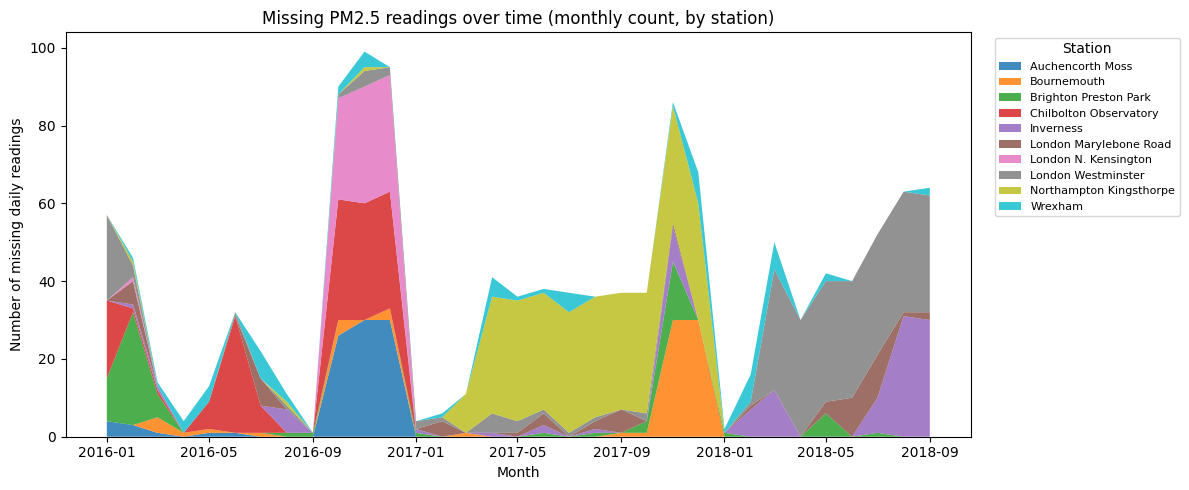

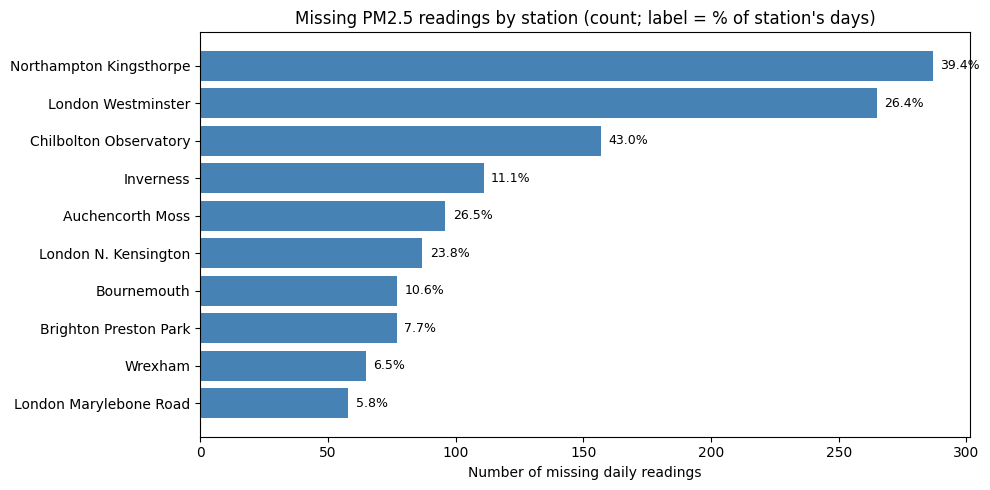


Worst stations by NA count:
                         na_count  pct_missing
station                                       
Northampton Kingsthorpe       287         39.4
London Westminster            265         26.4
Chilbolton Observatory        157         43.0
Inverness                     111         11.1
Auchencorth Moss               96         26.5
London N. Kensington           87         23.8
Brighton Preston Park          77          7.7
Bournemouth                    77         10.6
Wrexham                        65          6.5
London Marylebone Road         58          5.8

After dropping NA pm25_raw rows, shape: (6276, 6)


In [13]:
#how many NA's in pm25_raw? (these come from 'No data' / blank cells in the source CSVs)
na_pm25_count = df['pm25_raw'].isna().sum()
print(f'Number of NA values in pm25_raw: {na_pm25_count}')

# --- Plot 1: time span of NA's (monthly count, stacked by station) ---
na_rows = df[df['pm25_raw'].isna()].copy()
# station may be a pandas StringArray; cast to plain object so groupby/unstack
# produce a numeric-dtype matrix that plot(kind='area') accepts.
na_rows['station'] = na_rows['station'].astype(str)
na_rows['month'] = na_rows['date'].dt.to_period('M').dt.to_timestamp()
na_by_month_station = (na_rows.groupby(['month', 'station']).size()
                              .unstack(fill_value=0)
                              .sort_index()
                              .astype('int64'))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(na_by_month_station.index,
             na_by_month_station.T.values,
             labels=na_by_month_station.columns,
             alpha=0.85)
ax.set_title('Missing PM2.5 readings over time (monthly count, by station)')
ax.set_xlabel('Month')
ax.set_ylabel('Number of missing daily readings')
ax.legend(title='Station', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# --- Plot 2: worst stations (count + % of that station's days that are missing) ---
station_total = df.groupby('station').size()
station_na    = na_rows.groupby('station').size().reindex(station_total.index, fill_value=0)
station_pct   = (station_na / station_total * 100).round(1)

worst = (pd.DataFrame({'na_count': station_na, 'pct_missing': station_pct})
           .sort_values('na_count', ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(worst.index.astype(str), worst['na_count'].astype(int), color='steelblue')
for bar, pct in zip(bars, worst['pct_missing']):
    ax.text(bar.get_width() + max(worst['na_count']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=9)
ax.set_title("Missing PM2.5 readings by station (count; label = % of station's days)")
ax.set_xlabel('Number of missing daily readings')
plt.tight_layout()
plt.show()

print('\nWorst stations by NA count:')
print(worst.sort_values('na_count', ascending=False))

# Drop NA rows now that we've inspected them
df = df.dropna(subset=['pm25_raw'])
print(f'\nAfter dropping NA pm25_raw rows, shape: {df.shape}')

#### How many stations?

In [14]:
#how many stations?
print(f'Unique stations: {df["station"].nunique()}')
print(f'Station names: {df["station"].unique()}')

Unique stations: 10
Station names: ['Auchencorth Moss' 'Bournemouth' 'Brighton Preston Park'
 'Chilbolton Observatory' 'Inverness' 'London Marylebone Road'
 'London N. Kensington' 'London Westminster' 'Northampton Kingsthorpe'
 'Wrexham']


#### Assign region to each station

In [15]:
# Group stations into UK regions so downstream code can enforce geographic
# diversity (national rule) and report rural-vs-urban patterns. Defined once
# here and used everywhere — do not redefine this dict in later cells.
STATION_REGION = {
    'Auchencorth Moss':        'Scotland',
    'Inverness':               'Scotland',
    'Wrexham':                 'Wales',
    'Northampton Kingsthorpe': 'Midlands',
    'Bournemouth':             'South',
    'Brighton Preston Park':   'South',
    'Chilbolton Observatory':  'South',
    'London Marylebone Road':  'London',
    'London N. Kensington':    'London',
    'London Westminster':      'London',
}
df['region'] = df['station'].map(STATION_REGION)

# Sanity check: every station should have a region
unmapped = df.loc[df['region'].isna(), 'station'].unique()
print(f'Stations missing a region mapping: {list(unmapped) if len(unmapped) else "none"}')
print('\nStations per region:')
print(df.groupby('region')['station'].nunique().sort_values(ascending=False))

Stations missing a region mapping: none

Stations per region:
region
London      3
South       3
Scotland    2
Midlands    1
Wales       1
Name: station, dtype: int64


#### Duplicate checks

In [16]:
#duplicates are when the same station has multiple readings for the same date (should be 1 reading per station per day)
duplicates = df.groupby(['date', 'station']).size()
duplicate_rows = duplicates[duplicates > 1]
print(f'\nNumber of duplicate date-station pairs: {len(duplicate_rows)}')
if len(duplicate_rows):
    print('Duplicate date-station pairs (date, station, count):')
    print(duplicate_rows.reset_index(name='count').to_string(index=False))


Number of duplicate date-station pairs: 0


#### Outliers in PM2.5 values?

Global summary:
count    6276.00
mean        8.13
std         6.97
min         0.00
50%         6.00
90%        15.75
95%        21.16
99%        34.98
99.9%      60.26
max        92.22
Name: pm25_raw, dtype: float64

Readings above hard cap (250 ugm-3): 0

Per-station outlier summary (Q3 + 3*IQR rule):
                           n  median    p99    max  iqr_upper  n_outliers  \
station                                                                     
Brighton Preston Park    925    6.75  33.78  53.96      26.29          33   
Bournemouth              652    5.37  29.83  46.25      21.09          32   
Wrexham                  937    5.10  29.32  49.09      24.36          24   
London Marylebone Road   944   11.31  47.79  92.22      33.96          24   
London Westminster       737    7.00  42.63  79.63      28.42          24   
Northampton Kingsthorpe  441    5.00  37.04  48.71      25.40          20   
Inverness                888    3.75  17.70  30.94      13.57          19   
Lo

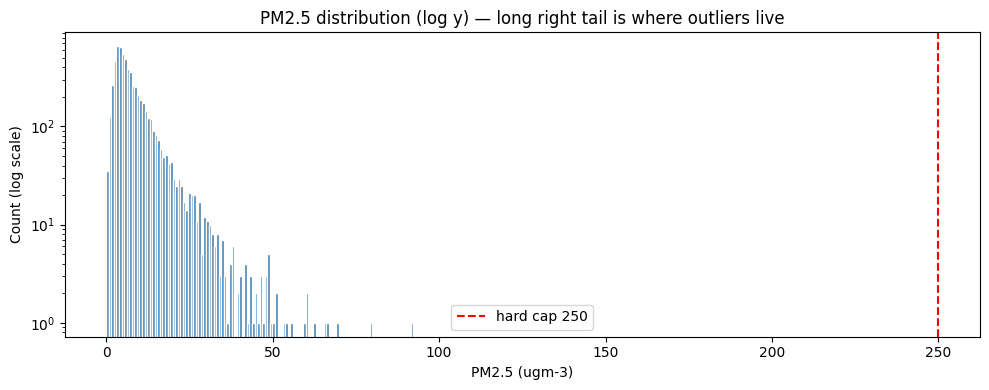

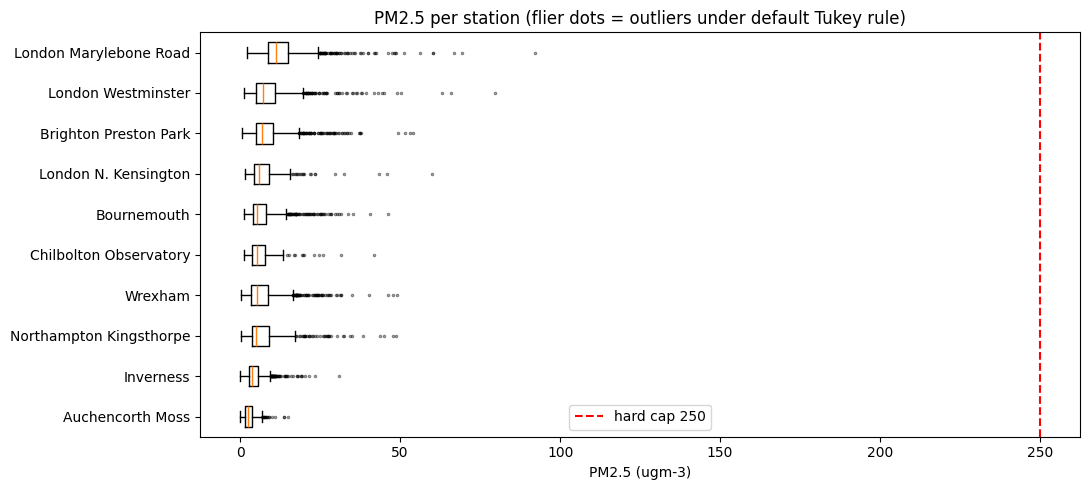

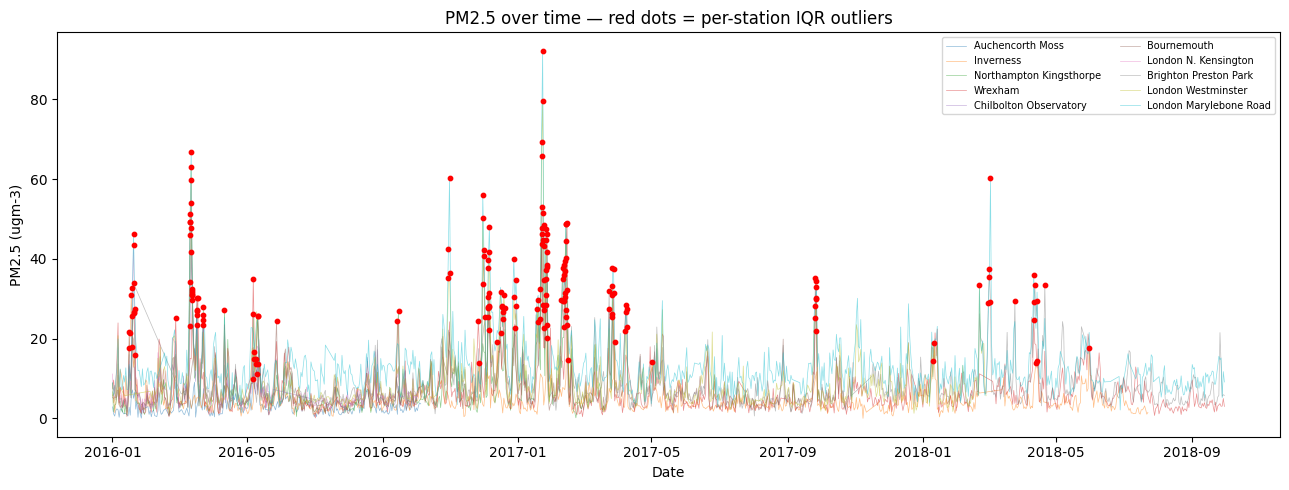

In [17]:
# --- Outlier inspection (no rows dropped here — just surface them) ---
# PM2.5 baselines differ a lot by site type (rural Auchencorth ~3 ugm-3 vs urban
# London Marylebone ~15 ugm-3), so a single global threshold is misleading.
# We check three lenses: hard cap, per-station IQR, and the top-N table.

PM25_HARD_CAP = 250  # Research actual limit?

print('Global summary:')
print(df['pm25_raw'].describe(percentiles=[.5, .9, .95, .99, .999]).round(2))

# 1) Hard cap
hard = df[df['pm25_raw'] > PM25_HARD_CAP]
print(f'\nReadings above hard cap ({PM25_HARD_CAP} ugm-3): {len(hard)}')
if len(hard):
    print(hard.sort_values('pm25_raw', ascending=False).head(10).to_string(index=False))

# 2) Per-station IQR rule (Tukey: > Q3 + 3*IQR is a "far" outlier)
# Use transform so the bound is broadcast back per row without losing the
# 'station' column (which groupby().apply() drops in newer pandas versions).
grouped = df.groupby('station')['pm25_raw']
q1 = grouped.transform(lambda s: s.quantile(0.25))
q3 = grouped.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
flagged = df.copy()
flagged['iqr_upper']  = q3 + 3 * iqr
flagged['is_outlier'] = flagged['pm25_raw'] > flagged['iqr_upper']

per_station = (flagged.groupby('station')
                      .agg(n=('pm25_raw', 'size'),
                           median=('pm25_raw', 'median'),
                           p99=('pm25_raw', lambda s: s.quantile(0.99)),
                           max=('pm25_raw', 'max'),
                           iqr_upper=('iqr_upper', 'first'),
                           n_outliers=('is_outlier', 'sum'))
                      .assign(pct_outliers=lambda d: (d['n_outliers'] / d['n'] * 100).round(2))
                      .sort_values('n_outliers', ascending=False))
print('\nPer-station outlier summary (Q3 + 3*IQR rule):')
print(per_station.round(2))

# 3) Top 20 highest readings (with status + station context)
print('\nTop 20 highest PM2.5 readings:')
print(df.nlargest(20, 'pm25_raw')[['date', 'station', 'pm25_raw', 'status_raw']]
        .to_string(index=False))

# --- Plot 1: distribution (log y, so the long tail is visible) ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['pm25_raw'].dropna(), bins=120, color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 distribution (log y) — long right tail is where outliers live')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.set_ylabel('Count (log scale)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: per-station boxplot, sorted by median ---
order = (df.groupby('station')['pm25_raw'].median()
           .sort_values().index.astype(str).tolist())
data_by_station = [df.loc[df['station'].astype(str) == s, 'pm25_raw'].values for s in order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(data_by_station, labels=order, vert=False, showfliers=True,
           flierprops=dict(marker='.', markersize=3, alpha=0.5))
ax.axvline(PM25_HARD_CAP, color='red', linestyle='--', label=f'hard cap {PM25_HARD_CAP}')
ax.set_title('PM2.5 per station (flier dots = outliers under default Tukey rule)')
ax.set_xlabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: time series with per-station outliers highlighted ---
fig, ax = plt.subplots(figsize=(13, 5))
for s in order:
    sub = flagged[flagged['station'].astype(str) == s].sort_values('date')
    ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.5, alpha=0.5, label=s)
    out = sub[sub['is_outlier']]
    ax.scatter(out['date'], out['pm25_raw'], s=10, color='red', zorder=3)
ax.set_title('PM2.5 over time — red dots = per-station IQR outliers')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()



```
# This is formatted as code
```



Plot 1 — Distribution (log y)
A histogram of every PM2.5 reading, with a log-scale y-axis so even single rare readings stay visible instead of being swallowed by the bulk near zero. Anything to the right of the red 250 µg/m³ line is implausibly high for the UK and worth a closer look.

Plot 2 — Per-station boxplot
Each row shows one station's spread, sorted by median, so you can see at a glance that rural sites (Auchencorth, Inverness) sit far below the London sites. The dots past the whiskers are each station's own outliers, proving a global threshold is wrong, because 20 µg/m³ is extreme for Auchencorth but routine for Marylebone.

Plot 3 — Time series with outliers highlighted
Every station's daily readings plotted over time, with red dots marking that station's per-station IQR outliers. If red dots cluster on the same dates across multiple stations they're likely real pollution events (dust, fireworks, wildfire); if they're scattered on one station only, they're more likely sensor faults.
darker bands = stations clustered together (similar readings), fainter strands = a station diverging from the pack.

#### Train, validation, test split

move the longest continuous-day reading streaks to here.


Time series models require a continuous sequence of data for training and validation. By moving the longest continuous-day reading streaks to the train, validation, and test split section, we can ensure that our models are trained on reliable and uninterrupted data. Other options for handling gaps in the data include interpolation, forward/backward filling, or using models that can handle missing data. However, using continuous streaks of data is often the most straightforward and effective approach for time series modeling and given we have 989 days of continuous data, we can use that for training and validation without too much concern of underfitting.

In [18]:
# --- Per-day national-rule indicator ---
# How many distinct stations / regions report on each day, reindexed to the
# full daily range so missing days show up as False (rule not met).
df_plot = df.copy()
df_plot['date'] = df_plot['date'].dt.normalize()
full_range = pd.date_range(df_plot['date'].min(), df_plot['date'].max(), freq='D')

per_date = df_plot.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
rule_mask   = (per_date['n_stations'] >= 3) & (per_date['n_regions'] >= 2)
rule_series = rule_mask.reindex(full_range, fill_value=False)
print(f'Days where national rule is met: {int(rule_series.sum())} of {len(rule_series)} '
      f'({rule_series.mean()*100:.1f}%)')


Days where national rule is met: 987 of 1004 (98.3%)


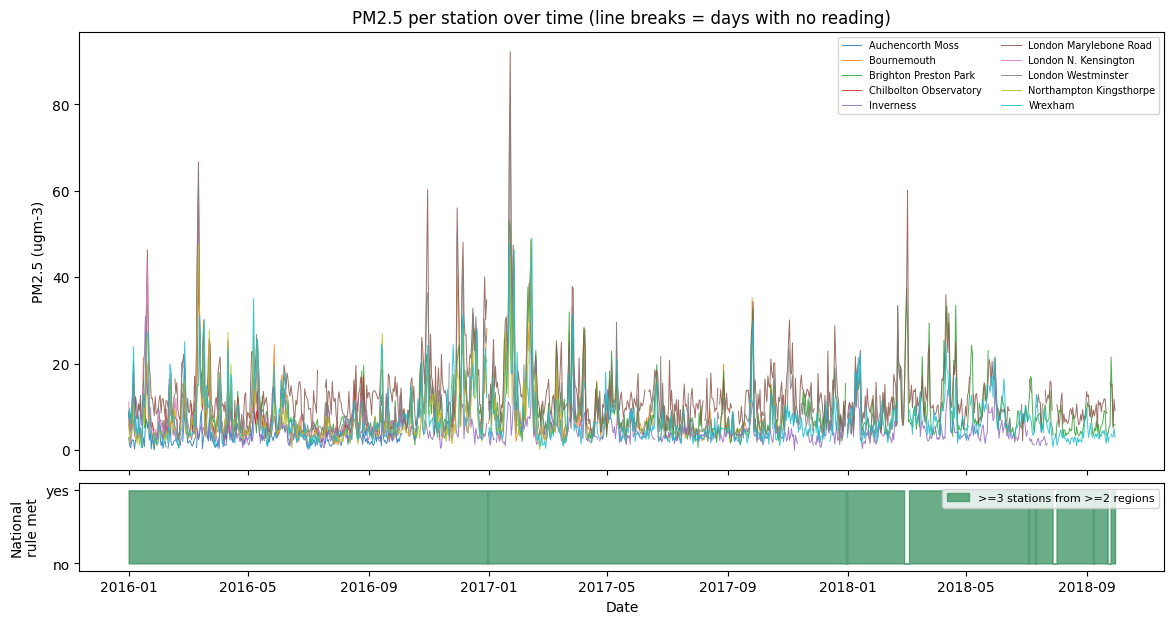

In [19]:
# --- Coverage plot: per-station lines + national-rule indicator ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(14, 7), sharex=True,
    gridspec_kw={'height_ratios': [5, 1], 'hspace': 0.05}
)

stations = sorted(df_plot['station'].astype(str).unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(stations)))
for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25_raw'].mean()
             .reindex(full_range))
    ax_top.plot(sub.index, sub.values, linewidth=0.7, alpha=0.85, color=c, label=s)

ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title('PM2.5 per station over time (line breaks = days with no reading)')
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(full_range, 0, rule_series.astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1])
ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()


In [20]:
# --- Find every contiguous run where the national rule fails ---
fail  = ~rule_series
group = (fail != fail.shift()).cumsum()
runs  = (pd.DataFrame({'date': rule_series.index,
                       'fail': fail.values, 'group': group.values})
           .query('fail')
           .groupby('group')
           .agg(start=('date', 'min'), end=('date', 'max'),
                length_days=('date', 'size'))
           .reset_index(drop=True))
print(f'Total rule-failure runs: {len(runs)}')
print(runs.head(10).to_string(index=False))


Total rule-failure runs: 8
     start        end  length_days
2016-12-31 2016-12-31            1
2017-12-31 2017-12-31            1
2018-02-28 2018-03-04            5
2018-07-04 2018-07-04            1
2018-07-11 2018-07-11            1
2018-07-29 2018-08-01            4
2018-09-08 2018-09-08            1
2018-09-23 2018-09-25            3


In [ ]:
# --- Gaps overlapping 2018 (sorted by length) ---
mask_2018 = (runs['start'].dt.year <= 2018) & (runs['end'].dt.year >= 2018)
gaps_2018 = runs[mask_2018].sort_values('length_days', ascending=False).copy()

print('Rule-failure gaps overlapping 2018:')
if gaps_2018.empty:
    print('  (none)')
else:
    print(gaps_2018.assign(start=gaps_2018['start'].dt.date,
                           end=gaps_2018['end'].dt.date)
                   .to_string(index=False))
    print(f'\nTotal rule-failing days inside 2018: '
          f'{int(fail.loc["2018"].sum())} of {len(fail.loc["2018"])}')


Rule-failure gaps overlapping 2018:
     start        end  length_days
2018-10-01 2020-12-31          823
2018-02-28 2018-03-04            5
2018-07-29 2018-08-01            4
2018-09-23 2018-09-25            3
2018-07-04 2018-07-04            1
2018-07-11 2018-07-11            1
2018-09-08 2018-09-08            1

Total rule-failing days inside 2018: 107 of 365


In [32]:
# --- Pick the biggest 2018-touching gap and its zoom window ---
# Re-defining full_range, mask_2018 and gaps_2018 to ensure they are available
# given a potential kernel state inconsistency or re-execution.
full_range = rule_series.index # Ensure full_range is defined

mask_2018 = (runs['start'].dt.year <= 2018) & (runs['end'].dt.year >= 2018)
gaps_2018 = runs[mask_2018].sort_values('length_days', ascending=False).copy()

gap = gaps_2018.iloc[0]   # already sorted by length descending

pad = pd.Timedelta(days=180)
win_start = max(gap['start'] - pad, full_range.min())
win_end   = min(gap['end']   + pad, full_range.max())
zoom_idx  = full_range[(full_range >= win_start) & (full_range <= win_end)]

print(f"Gap: {gap['start'].date()} -> {gap['end'].date()} "
      f"({gap['length_days']} days)")
print(f"Zoom window: {win_start.date()} -> {win_end.date()} ({len(zoom_idx)} days)")

Gap: 2018-02-28 -> 2018-03-04 (5 days)
Zoom window: 2017-09-01 -> 2018-08-31 (365 days)


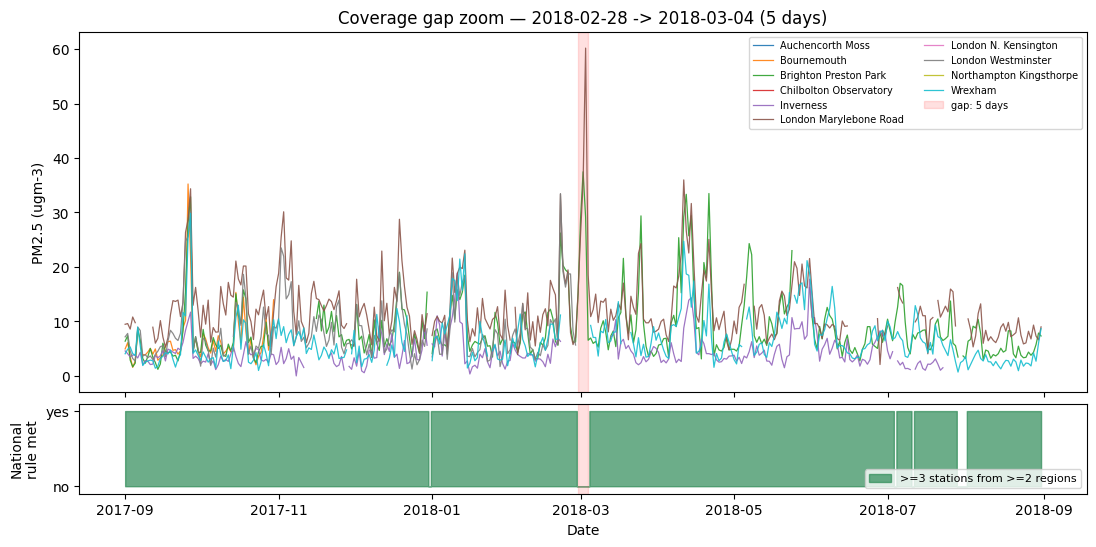

In [33]:
# --- Zoomed coverage plot around the chosen gap ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
)

for s, c in zip(stations, colors):
    sub = (df_plot[df_plot['station'].astype(str) == s]
             .groupby('date')['pm25_raw'].mean()
             .reindex(zoom_idx))
    ax_top.plot(sub.index, sub.values, linewidth=0.9, alpha=0.9, color=c, label=s)

ax_top.axvspan(gap['start'], gap['end'], color='red', alpha=0.12,
               label=f"gap: {gap['length_days']} days")
ax_top.set_ylabel('PM2.5 (ugm-3)')
ax_top.set_title(f"Coverage gap zoom — {gap['start'].date()} -> {gap['end'].date()} "
                 f"({gap['length_days']} days)")
ax_top.legend(fontsize=7, ncol=2, loc='upper right')

ax_bot.fill_between(zoom_idx, 0, rule_series.loc[zoom_idx].astype(int).values,
                    step='mid', color='seagreen', alpha=0.7,
                    label='>=3 stations from >=2 regions')
ax_bot.axvspan(gap['start'], gap['end'], color='red', alpha=0.12)
ax_bot.set_ylim(-0.1, 1.1)
ax_bot.set_yticks([0, 1]); ax_bot.set_yticklabels(['no', 'yes'])
ax_bot.set_xlabel('Date'); ax_bot.set_ylabel('National\nrule met')
ax_bot.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()


#### Longest consecutive-day reading streaks

In [34]:
# --- Helper: longest consecutive-day run in a date series ---
def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']


In [35]:
# --- Longest streak per station ---
rows = []
for station, sub in df.groupby('station'):
    n, start, end = longest_run(sub['date'])
    rows.append({'station': station, 'longest_run_days': n,
                 'start': start.date(), 'end': end.date()})
per_station_runs = (pd.DataFrame(rows)
                      .sort_values('longest_run_days', ascending=False)
                      .reset_index(drop=True))
print('Longest consecutive-day streak per station:')
print(per_station_runs.to_string(index=False))


Longest consecutive-day streak per station:
                station  longest_run_days      start        end
       Auchencorth Moss              1004 2016-01-01 2018-09-30
            Bournemouth              1004 2016-01-01 2018-09-30
  Brighton Preston Park              1004 2016-01-01 2018-09-30
 Chilbolton Observatory              1004 2016-01-01 2018-09-30
              Inverness              1004 2016-01-01 2018-09-30
 London Marylebone Road              1004 2016-01-01 2018-09-30
   London N. Kensington              1004 2016-01-01 2018-09-30
     London Westminster              1004 2016-01-01 2018-09-30
Northampton Kingsthorpe              1004 2016-01-01 2018-09-30
                Wrexham              1004 2016-01-01 2018-09-30


In [36]:
# --- Longest streak for the national rule ---
per_date_full = df.groupby('date').agg(n_stations=('station', 'nunique'),
                                       n_regions=('region', 'nunique'))
national_dates = per_date_full[(per_date_full['n_stations'] >= 3) &
                               (per_date_full['n_regions']  >= 2)].index.to_series()
n, start, end = longest_run(national_dates)
print(f'National rule (>=3 stations, >=2 regions):')
print(f'  longest gap-free run: {n} days  ({start.date()} -> {end.date()})')
print(f'  total qualifying days: {len(national_dates)}')


National rule (>=3 stations, >=2 regions):
  longest gap-free run: 1004 days  (2016-01-01 -> 2018-09-30)
  total qualifying days: 1004


## What do about the gaps?

It appears that post 09 2018, large gaps in the data appear and continue to voliate our national rule from this point forward. We can either drop these stations entirely, or we can use interpolation to fill in the gaps.

We will drop all data after 09 2018, as this is the point where the data becomes unreliable and violates our national rule and there is no reasonable way to interpolate the data without introducing bias or inaccuracies. By dropping this data, we can ensure that our analysis and modeling are based on reliable and consistent data.

#### Filling gaps pre 09 2018:

The gaps in the data pre 09 2018 are relatively small and can be filled using interpolation.

We will use multiple methods for this:

Short gaps - Linear interpolation: For gaps of 1-2 days, we can use linear interpolation to fill in the missing values. This method assumes that the change between the two known values is linear and can be used to estimate the missing value. This will create 'straight lines' between the known values, which is a reasonable assumption for short gaps.

Medium gaps - Cross-station regression: For gaps of 3+ days, we can use cross-station regression to fill in the missing values. This method uses the readings from co-reporting stations to estimate the missing value based on the relationship between the stations. This will create a more accurate estimate of the missing value, as it takes into account the readings from other stations.

In order to use cross-station regression, we will need to first split our data into training and testing sets. We will use the training set to build the regression model and the testing set to evaluate its performance. This will prevent data leakage.

## Chronological split:

Chronological split is a method of splitting the data into training, validation, and test sets based on time. This is important for time series modeling, as it ensures that the model is trained on past data and tested on future data.

In [37]:
# --- Universe and split window definitions ---
# Restrict the modelling universe to the pre-cliff period and split it
# chronologically (never shuffled).
UNIVERSE_START = '2016-01-01'
UNIVERSE_END   = '2018-09-30'

SPLITS = [
    ('train', '2016-01-01', '2017-12-31'),   # 24 mo, two full seasonal cycles
    ('val',   '2018-01-01', '2018-04-30'),   # 4 mo, hyperparameter tuning
    ('test',  '2018-05-01', '2018-09-30'),   # 5 mo, held-out forecast window
]


In [38]:
# --- Filter to the universe and assign a split label to every row ---
in_universe = (df['date'] >= pd.Timestamp(UNIVERSE_START)) & \
              (df['date'] <= pd.Timestamp(UNIVERSE_END))
df = df[in_universe].copy()

def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return 'unassigned'

df['split'] = df['date'].apply(assign_split).astype('category')
print(f'Universe: {UNIVERSE_START} -> {UNIVERSE_END}')
print(f'Total rows after restriction: {len(df)}')


Universe: 2016-01-01 -> 2018-09-30
Total rows after restriction: 10040


In [40]:
summary = (df.groupby('split', observed=True)
             .agg(rows=('pm25_raw', 'size'),
                  first_date=('date', 'min'),
                  last_date=('date', 'max'),
                  n_stations=('station', 'nunique'),
                  n_regions=('region', 'nunique'))
             .reindex([name for name, _, _ in SPLITS]))
print(summary.to_string())

       rows first_date  last_date  n_stations  n_regions
split                                                   
train  7310 2016-01-01 2017-12-31          10          5
val    1200 2018-01-01 2018-04-30          10          5
test   1530 2018-05-01 2018-09-30          10          5


In [41]:
# --- Convenience slices + sanity check ---
train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()
print(f"Shapes -> train: {train_df.shape}, val: {val_df.shape}, test: {test_df.shape}")

overlap = (df.groupby(['date', 'station'])['split'].nunique() > 1).sum()
print(f'Rows where the same (date, station) lands in 2+ splits: {overlap}  (should be 0)')


Shapes -> train: (7310, 6), val: (1200, 6), test: (1530, 6)
Rows where the same (date, station) lands in 2+ splits: 0  (should be 0)


In [42]:
# --- Pivot to wide (date x station) for per-station interpolation ---
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

wide = (df.pivot_table(index='date', columns='station',
                       values='pm25_raw', aggfunc='mean')
          .reindex(pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D')))
observed = wide.notna()  # snapshot of what was observed before any filling
print(f'Wide matrix shape: {wide.shape}  (rows = days, cols = stations)')
print(f'Cells observed: {int(observed.sum().sum())};  cells NaN: {int((~observed).sum().sum())}')


Wide matrix shape: (1004, 10)  (rows = days, cols = stations)
Cells observed: 10040;  cells NaN: 0


In [43]:
# --- Per-cell NaN-run length ---
# For each NaN cell, store the length of the run it belongs to; observed cells = 0.
def gap_run_length(col):
    is_na = col.isna()
    grp = (is_na != is_na.shift()).cumsum()
    return is_na.groupby(grp).transform('size') * is_na.astype(int)
gap_len = wide.apply(gap_run_length)

run_dist = (gap_len.stack(future_stack=True)
                   .pipe(lambda s: s[s > 0])
                   .value_counts()
                   .sort_index())
print('Per-station NaN-run length distribution (length -> cells):')
print(run_dist.to_string())


Per-station NaN-run length distribution (length -> cells):
Series([], )


In [44]:
# --- Tier 1: linear interpolation for runs of length 1-2 ---
linear_filled = wide.interpolate(method='linear', limit=2, limit_area='inside')
short_mask = (gap_len >= 1) & (gap_len <= 2)
wide_after_short = wide.where(~short_mask, linear_filled)
n_short = int((wide.isna() & wide_after_short.notna()).sum().sum())
print(f'Cells linear-interpolated (1-2 day runs): {n_short}')


Cells linear-interpolated (1-2 day runs): 0


In [45]:
# --- Tier 2: cross-station regression for any gap >=3 days ---
# Fit on TRAIN rows only so val/test never inform the regression coefficients.
train_lo, train_hi = SPLITS[0][1], SPLITS[0][2]
train_rows = (wide_after_short.index >= pd.Timestamp(train_lo)) & \
             (wide_after_short.index <= pd.Timestamp(train_hi))

imputer = IterativeImputer(estimator=BayesianRidge(),
                           random_state=0, max_iter=25)
imputer.fit(wide_after_short.loc[train_rows].values)
predicted = pd.DataFrame(imputer.transform(wide_after_short.values),
                         index=wide_after_short.index,
                         columns=wide_after_short.columns)

medium_mask = (gap_len >= 3)
wide_filled = wide_after_short.where(~medium_mask, predicted)
n_medium = int((wide_after_short.isna() & wide_filled.notna()).sum().sum())
n_left   = int(wide_filled.isna().sum().sum())
print(f'Cells regression-imputed (>=3 day runs): {n_medium}')
print(f'Cells left as NaN (imputer NaN):        {n_left}')


Cells regression-imputed (>=3 day runs): 0
Cells left as NaN (imputer NaN):        0


In [46]:
# --- Rebuild long-format df with pm25_imputed flag ---
long_pm25 = (wide_filled.stack(future_stack=True)
                        .rename('pm25_raw')
                        .reset_index())
long_pm25.columns = ['date', 'station', 'pm25_raw']
long_obs = observed.stack(future_stack=True).rename('was_observed').reset_index()
long_obs.columns = ['date', 'station', 'was_observed']

df = long_pm25.merge(long_obs, on=['date', 'station'])
df = df.dropna(subset=['pm25_raw']).reset_index(drop=True)
df['pm25_imputed'] = ~df['was_observed']
df = df.drop(columns=['was_observed'])
df['region'] = df['station'].map(STATION_REGION)
df['split']  = df['date'].apply(assign_split).astype('category')

print(f'Long-format df after interpolation: {df.shape}')
print(f'  observed rows: {(~df["pm25_imputed"]).sum()}')
print(f'  imputed rows:  {df["pm25_imputed"].sum()}')
print('\nImputed rows per split:')
print(df.groupby('split', observed=True)['pm25_imputed']
        .agg(['size', 'sum'])
        .rename(columns={'size': 'rows', 'sum': 'imputed'})
        .assign(pct_imputed=lambda d: (d['imputed'] / d['rows'] * 100).round(2))
        .to_string())


Long-format df after interpolation: (10040, 6)
  observed rows: 10040
  imputed rows:  0

Imputed rows per split:
       rows  imputed  pct_imputed
split                            
test   1530        0          0.0
train  7310        0          0.0
val    1200        0          0.0


In [47]:
# --- Aggregate per date: mean PM2.5 + coverage diagnostics ---
national = (df.groupby('date', as_index=False)
              .agg(pm25=('pm25_raw', 'mean'),
                   n_stations=('station', 'nunique'),
                   n_regions=('region', 'nunique'),
                   split=('split', 'first')))
print(f'National shape (before reindex): {national.shape}')


National shape (before reindex): (1004, 5)


In [48]:
# --- Strict daily index across the universe so any gaps stay visible ---
full_idx = pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D', name='date')
national = national.set_index('date').reindex(full_idx).reset_index()
national['split'] = (national['split']
                     .fillna(national['date'].apply(assign_split))
                     .astype('category'))
print(f'National shape (after reindex): {national.shape}')
print(f'Rows added by reindex (no station reported): {national["pm25"].isna().sum()}')


National shape (after reindex): (1004, 5)
Rows added by reindex (no station reported): 0


In [49]:
# --- Mask rule-failing days to NaN + per-split summary ---
rule_fails = ((national['n_stations'].fillna(0) < 3) |
              (national['n_regions'].fillna(0)  < 2))
national.loc[rule_fails, 'pm25'] = np.nan

print(f'Days masked as NaN (no rule-quality reading): {int(rule_fails.sum())}')
print('\nPer-split summary of national series:')
print(national.groupby('split', observed=True)
              .agg(rows=('pm25', 'size'),
                   missing=('pm25', lambda s: int(s.isna().sum())),
                   mean_pm25=('pm25', 'mean'),
                   median_pm25=('pm25', 'median'),
                   min_stations=('n_stations', 'min'),
                   max_stations=('n_stations', 'max'))
              .round(2)
              .to_string())
print('\nHead:')
print(national.head().to_string(index=False))


Days masked as NaN (no rule-quality reading): 0

Per-split summary of national series:
       rows  missing  mean_pm25  median_pm25  min_stations  max_stations
split                                                                   
test    153        0       6.35         5.78            10            10
train   731        0       7.75         5.93            10            10
val     120        0       8.39         6.59            10            10

Head:
      date     pm25  n_stations  n_regions split
2016-01-01 7.244076          10          5 train
2016-01-02 4.859983          10          5 train
2016-01-03 4.836537          10          5 train
2016-01-04 5.354490          10          5 train
2016-01-05 7.781772          10          5 train


In [50]:
def find_rule_gaps(df, split_name):
    sub = df[df['split'] == split_name]
    per_day = sub.groupby('date').agg(n_stations=('station', 'nunique'),
                                      n_regions=('region', 'nunique'))
    rule_ok = (per_day['n_stations'] >= 3) & (per_day['n_regions'] >= 2)
    all_dates = pd.date_range(per_day.index.min(), per_day.index.max())
    # missing = physically absent OR present but fails the rule
    physically_missing = all_dates.difference(per_day.index)
    rule_failing       = per_day.index[~rule_ok]
    return physically_missing.union(rule_failing).sort_values()

for split_name in ['train', 'val', 'test']:
    gaps = find_rule_gaps(df, split_name)
    print(f"{split_name}: {len(gaps)} day(s) failing national rule")
    if len(gaps):
        print(f"  {list(gaps.strftime('%Y-%m-%d'))}")

train: 0 day(s) failing national rule
val: 0 day(s) failing national rule
test: 0 day(s) failing national rule


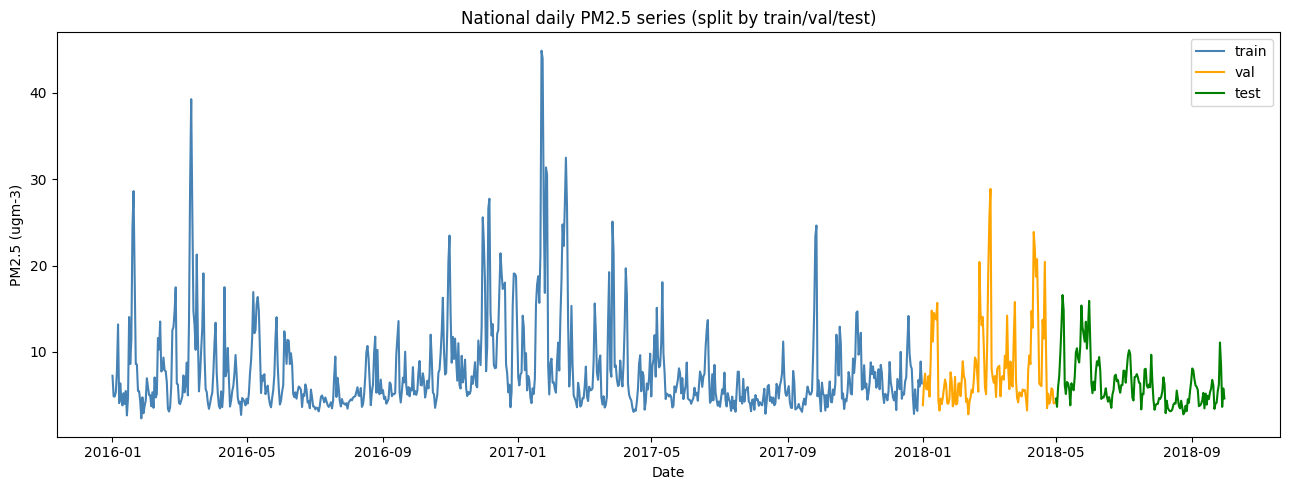

In [51]:
#plot time series of each split

fig, ax = plt.subplots(figsize=(13, 5))
for split_name, color in zip(['train', 'val', 'test'], ['steelblue', 'orange', 'green']):
    sub = national[national['split'] == split_name]
    ax.plot(sub['date'], sub['pm25'], label=split_name, color=color)
ax.set_title('National daily PM2.5 series (split by train/val/test)')
ax.set_xlabel('Date'); ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend()
plt.tight_layout()
plt.show()


---# Additional Analysis

Builds directly on the cleaned `df` and `national` dataframes above.
Covers: Seasonal Decomposition · COVID-19 Impact · Station Correlation · Feature Engineering · Rolling Statistics

## Imports

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import warnings
warnings.filterwarnings('ignore')

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Helper function for longest run (from cell a457c37c)
def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']

# Re-define STATION_REGION as it's used directly in covid-code and corr-code
STATION_REGION = {
    'Auchencorth Moss':        'Scotland',
    'Inverness':               'Scotland',
    'Wrexham':                 'Wales',
    'Northampton Kingsthorpe': 'Midlands',
    'Bournemouth':             'South',
    'Brighton Preston Park':   'South',
    'Chilbolton Observatory':  'South',
    'London Marylebone Road':  'London',
    'London N. Kensington':    'London',
    'London Westminster':      'London',
}

# --- File 1: Multi-station 2016-2020 (combined from individual year files) ---
files_2016_2020 = {
    '2016': '/content/AirQualityDataDaily_2016.csv',
    '2017': '/content/AirQualityDataDaily_2017.csv',
    '2018': '/content/AirQualityDataDaily_2018.csv',
    '2019': '/content/AirQualityDataDaily_2019.csv',
    '2020': '/content/AirQualityDataDaily_2020.csv'
}

all_records_2016_2020 = []
for year, file_path in files_2016_2020.items():
    # Read header for station names from each file
    header_row = pd.read_csv(file_path, skiprows=3, nrows=1, header=None)
    station_names = header_row.iloc[0].tolist()

    raw_year_df = pd.read_csv(file_path, skiprows=11, header=None)

    col_idx = 1
    station_idx = 1
    while col_idx < raw_year_df.shape[1] - 1:
        sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
        if pd.isna(sname) or str(sname).strip() == '':
            col_idx += 2; station_idx += 2; continue
        values = raw_year_df.iloc[:, col_idx]
        status = raw_year_df.iloc[:, col_idx + 1] if col_idx + 1 < raw_year_df.shape[1] else [None]*len(raw_year_df)
        for d, v, s in zip(raw_year_df.iloc[:, 0], values, status):
            all_records_2016_2020.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
        col_idx += 2; station_idx += 2

df1 = pd.DataFrame(all_records_2016_2020)

# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# Parse the 'date' column to datetime and normalize (from cell a69fa6b8)
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()

# Parse pm25_raw into numeric, errors as NaN (from cell 93cc7974)
df['pm25_raw'] = pd.to_numeric(df['pm25_raw'], errors='coerce')

# Fill actual NaN values in status_raw with 'Unverified' (from cell e0397e97)
df['status_raw'] = df['status_raw'].fillna('Unverified')

# Drop negative PM2.5 values (from cell 684ff7ab)
df = df[~(df['pm25_raw'] < 0)]

# Add region (from cell c417d7ff)
df['region'] = df['station'].map(STATION_REGION)

# Chronological split definitions (from cell 1649d37c)
UNIVERSE_START = '2016-01-01'
UNIVERSE_END   = '2018-09-30'
SPLITS = [
    ('train', '2016-01-01', '2017-12-31'),
    ('val',   '2018-01-01', '2018-04-30'),
    ('test',  '2018-05-01', '2018-09-30'),
]

# Filter to the universe and assign a split label to every row (from cell ec8cb5df)
in_universe = (df['date'] >= pd.Timestamp(UNIVERSE_START)) & \
              (df['date'] <= pd.Timestamp(UNIVERSE_END))
df = df[in_universe].copy()

def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return 'unassigned'

df['split'] = df['date'].apply(assign_split).astype('category')

# Pivot to wide (date x station) for per-station imputation (from cell 827ecd8c)
wide = (df.pivot_table(index='date', columns='station',
                       values='pm25_raw', aggfunc='mean')
          .reindex(pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D')))
observed = wide.notna()

# Per-cell NaN-run length (from cell 44c2591f)
def gap_run_length(col):
    is_na = col.isna()
    grp = (is_na != is_na.shift()).cumsum()
    return is_na.groupby(grp).transform('size') * is_na.astype(int)
gap_len = wide.apply(gap_run_length)

# Tier 1: linear interpolation for runs of length 1-2 (from cell 86da37b2)
linear_filled = wide.interpolate(method='linear', limit=2, limit_area='inside')
short_mask = (gap_len >= 1) & (gap_len <= 2)
wide_after_short = wide.where(~short_mask, linear_filled)

# Tier 2: cross-station regression for any gap >=3 days (from cell 4550ebbe)
train_lo, train_hi = SPLITS[0][1], SPLITS[0][2]
train_rows = (wide_after_short.index >= pd.Timestamp(train_lo)) & \
             (wide_after_short.index <= pd.Timestamp(train_hi))

imputer = IterativeImputer(estimator=BayesianRidge(),
                           random_state=0, max_iter=25)
imputer.fit(wide_after_short.loc[train_rows].values)
predicted = pd.DataFrame(imputer.transform(wide_after_short.values),
                         index=wide_after_short.index,
                         columns=wide_after_short.columns)

medium_mask = (gap_len >= 3)
wide_filled = wide_after_short.where(~medium_mask, predicted)

# Rebuild long-format df with pm25_imputed flag (from cell 7c0190b1)
long_pm25 = (wide_filled.stack(future_stack=True)
                        .rename('pm25_raw')
                        .reset_index())
long_pm25.columns = ['date', 'station', 'pm25_raw']
long_obs = observed.stack(future_stack=True).rename('was_observed').reset_index()
long_obs.columns = ['date', 'station', 'was_observed']

df = long_pm25.merge(long_obs, on=['date', 'station'])
df = df.dropna(subset=['pm25_raw']).reset_index(drop=True)
df['pm25_imputed'] = ~df['was_observed']
df = df.drop(columns=['was_observed'])
df['region'] = df['station'].map(STATION_REGION)
df['split']  = df['date'].apply(assign_split).astype('category')

# Aggregate per date: mean PM2.5 + coverage diagnostics (from cell d6a8ccc6)
national = (df.groupby('date', as_index=False)
              .agg(pm25=('pm25_raw', 'mean'),
                   n_stations=('station', 'nunique'),
                   n_regions=('region', 'nunique'),
                   split=('split', 'first')))

# Strict daily index across the universe so any gaps stay visible (from cell 9bd87554)
full_idx = pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D', name='date')
national = national.set_index('date').reindex(full_idx).reset_index()
national['split'] = (national['split']
                     .fillna(national['date'].apply(assign_split))
                     .astype('category'))

# Mask rule-failing days to NaN (from cell 2671b56b)
rule_fails = ((national['n_stations'].fillna(0) < 3) | \
              (national['n_regions'].fillna(0)  < 2))
national.loc[rule_fails, 'pm25'] = np.nan

print("DataFrames 'df' and 'national' have been set up for additional analysis.")

DataFrames 'df' and 'national' have been set up for additional analysis.


---
## 1. Seasonal Decomposition
Breaks down the national PM2.5 signal into trend, seasonality, and residual components. Reveals winter peaks, summer dips, and long-term trends in UK air quality.

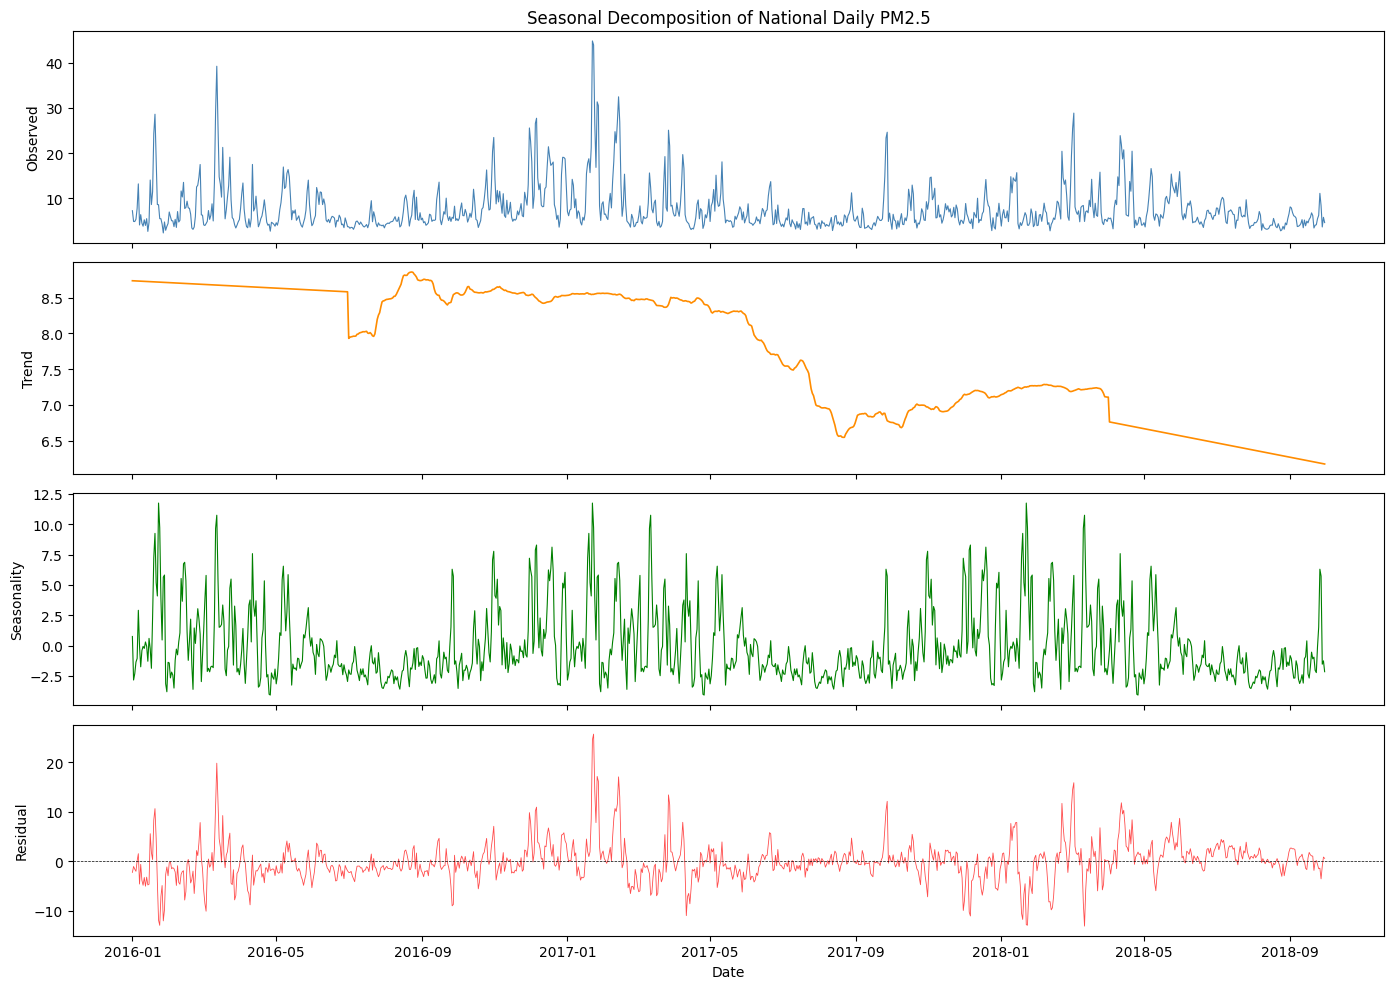

In [55]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use the national daily series
national_series = national.set_index('date')['pm25'].copy()
national_series = national_series.interpolate(method='linear')

# Seasonal decomposition (period=365 for annual seasonality)
decomp = seasonal_decompose(national_series, model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomp.observed.index, decomp.observed, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Seasonal Decomposition of National Daily PM2.5')
axes[1].plot(decomp.trend.index, decomp.trend, linewidth=1.2, color='darkorange')
axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal.index, decomp.seasonal, linewidth=0.8, color='green')
axes[2].set_ylabel('Seasonality')
axes[3].plot(decomp.resid.index, decomp.resid, linewidth=0.6, color='red', alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('pm25_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

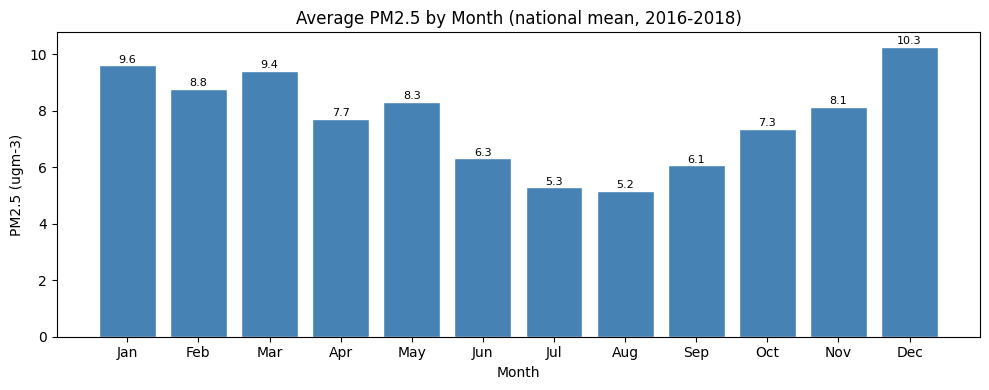

Peak month   : Dec (10.26 ugm-3)
Lowest month : Aug (5.16 ugm-3)


In [56]:
# Monthly average PM2.5
national_copy = national.copy()
national_copy['month'] = pd.to_datetime(national_copy['date']).dt.month
monthly_avg = national_copy.groupby('month')['pm25'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average PM2.5 by Month (national mean, 2016-2018)')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.set_xlabel('Month')
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('pm25_monthly_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak month   : {month_names[monthly_avg.idxmax()-1]} ({monthly_avg.max():.2f} ugm-3)')
print(f'Lowest month : {month_names[monthly_avg.idxmin()-1]} ({monthly_avg.min():.2f} ugm-3)')

---
## 2. COVID-19 Impact Analysis
Compares PM2.5 levels during the March-June window across years. The first UK lockdown began 23 March 2020, likely showing a measurable PM2.5 drop.

In [29]:
# Cell  dataframes: Consolidate data loading, cleaning, imputation, and splitting
from sklearn.experimental import enable_iterative_imputer # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Helper function for longest run (from cell a457c37c)
def longest_run(dates: pd.Series) -> tuple[int, pd.Timestamp, pd.Timestamp]:
    """Return (length, start, end) of the longest run of consecutive daily dates."""
    if dates.empty:
        return 0, pd.NaT, pd.NaT
    d = pd.to_datetime(pd.Series(dates).dt.normalize().unique())
    d = pd.Series(d).sort_values().reset_index(drop=True)
    gap   = d.diff().dt.days.fillna(1)
    group = (gap != 1).cumsum()
    runs  = d.groupby(group).agg(['min', 'max', 'count'])
    best  = runs.loc[runs['count'].idxmax()]
    return int(best['count']), best['min'], best['max']

# Re-define STATION_REGION as it's used directly in covid-code and corr-code
STATION_REGION = {
    'Auchencorth Moss':        'Scotland',
    'Inverness':               'Scotland',
    'Wrexham':                 'Wales',
    'Northampton Kingsthorpe': 'Midlands',
    'Bournemouth':             'South',
    'Brighton Preston Park':   'South',
    'Chilbolton Observatory':  'South',
    'London Marylebone Road':  'London',
    'London N. Kensington':    'London',
    'London Westminster':      'London',
}

# --- File 1: Multi-station 2016-2020 (combined from individual year files) ---
files_2016_2020 = {
    '2016': '/content/AirQualityDataDaily_2016.csv',
    '2017': '/content/AirQualityDataDaily_2017.csv',
    '2018': '/content/AirQualityDataDaily_2018.csv',
    '2019': '/content/AirQualityDataDaily_2019.csv',
    '2020': '/content/AirQualityDataDaily_2020.csv'
}

all_records_2016_2020 = []
for year, file_path in files_2016_2020.items():
    # Read header for station names from each file
    header_row = pd.read_csv(file_path, skiprows=3, nrows=1, header=None)
    station_names = header_row.iloc[0].tolist()

    raw_year_df = pd.read_csv(file_path, skiprows=11, header=None)

    col_idx = 1
    station_idx = 1
    while col_idx < raw_year_df.shape[1] - 1:
        sname = station_names[station_idx] if station_idx < len(station_names) else f'Station_{col_idx}'
        if pd.isna(sname) or str(sname).strip() == '':
            col_idx += 2; station_idx += 2; continue
        values = raw_year_df.iloc[:, col_idx]
        status = raw_year_df.iloc[:, col_idx + 1] if col_idx + 1 < raw_year_df.shape[1] else [None]*len(raw_year_df)
        for d, v, s in zip(raw_year_df.iloc[:, 0], values, status):
            all_records_2016_2020.append({'date': d, 'station': str(sname).strip(), 'pm25_raw': v, 'status_raw': s})
        col_idx += 2; station_idx += 2

df1 = pd.DataFrame(all_records_2016_2020)

# --- File 2: Single station 2020-2025 ---
df2 = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv', skiprows=11, header=None,
                  names=['date', 'pm25_raw', 'status_raw'])
df2['station'] = 'London Marylebone Road'
df2 = df2[['date', 'station', 'pm25_raw', 'status_raw']]

# Combine
df = pd.concat([df1, df2], ignore_index=True)

# Parse the 'date' column to datetime and normalize (from cell a69fa6b8)
df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.normalize()

# Parse pm25_raw into numeric, errors as NaN (from cell 93cc7974)
df['pm25_raw'] = pd.to_numeric(df['pm25_raw'], errors='coerce')

# Fill actual NaN values in status_raw with 'Unverified' (from cell e0397e97)
df['status_raw'] = df['status_raw'].fillna('Unverified')

# Drop negative PM2.5 values (from cell 684ff7ab)
df = df[~(df['pm25_raw'] < 0)]

# Add region (from cell c417d7ff)
df['region'] = df['station'].map(STATION_REGION)

# Chronological split definitions (from cell 1649d37c)
UNIVERSE_START = '2016-01-01'
UNIVERSE_END   = '2018-09-30'
SPLITS = [
    ('train', '2016-01-01', '2017-12-31'),
    ('val',   '2018-01-01', '2018-04-30'),
    ('test',  '2018-05-01', '2018-09-30'),
]

# Filter to the universe and assign a split label to every row (from cell ec8cb5df)
in_universe = (df['date'] >= pd.Timestamp(UNIVERSE_START)) & \
              (df['date'] <= pd.Timestamp(UNIVERSE_END))
df = df[in_universe].copy()

def assign_split(d):
    for name, lo, hi in SPLITS:
        if pd.Timestamp(lo) <= d <= pd.Timestamp(hi):
            return name
    return 'unassigned'

df['split'] = df['date'].apply(assign_split).astype('category')

# Pivot to wide (date x station) for per-station imputation (from cell 827ecd8c)
wide = (df.pivot_table(index='date', columns='station',
                       values='pm25_raw', aggfunc='mean')
          .reindex(pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D')))
observed = wide.notna()

# Per-cell NaN-run length (from cell 44c2591f)
def gap_run_length(col):
    is_na = col.isna()
    grp = (is_na != is_na.shift()).cumsum()
    return is_na.groupby(grp).transform('size') * is_na.astype(int)
gap_len = wide.apply(gap_run_length)

# Tier 1: linear interpolation for runs of length 1-2 (from cell 86da37b2)
linear_filled = wide.interpolate(method='linear', limit=2, limit_area='inside')
short_mask = (gap_len >= 1) & (gap_len <= 2)
wide_after_short = wide.where(~short_mask, linear_filled)

# Tier 2: cross-station regression for any gap >=3 days (from cell 4550ebbe)
train_lo, train_hi = SPLITS[0][1], SPLITS[0][2]
train_rows = (wide_after_short.index >= pd.Timestamp(train_lo)) & \
             (wide_after_short.index <= pd.Timestamp(train_hi))

imputer = IterativeImputer(estimator=BayesianRidge(),
                           random_state=0, max_iter=25)
imputer.fit(wide_after_short.loc[train_rows].values)
predicted = pd.DataFrame(imputer.transform(wide_after_short.values),
                         index=wide_after_short.index,
                         columns=wide_after_short.columns)

medium_mask = (gap_len >= 3)
wide_filled = wide_after_short.where(~medium_mask, predicted)

# Rebuild long-format df with pm25_imputed flag (from cell 7c0190b1)
long_pm25 = (wide_filled.stack(future_stack=True)
                        .rename('pm25_raw')
                        .reset_index())
long_pm25.columns = ['date', 'station', 'pm25_raw']
long_obs = observed.stack(future_stack=True).rename('was_observed').reset_index()
long_obs.columns = ['date', 'station', 'was_observed']

df = long_pm25.merge(long_obs, on=['date', 'station'])
df = df.dropna(subset=['pm25_raw']).reset_index(drop=True)
df['pm25_imputed'] = ~df['was_observed']
df = df.drop(columns=['was_observed'])
df['region'] = df['station'].map(STATION_REGION)
df['split']  = df['date'].apply(assign_split).astype('category')

# Aggregate per date: mean PM2.5 + coverage diagnostics (from cell d6a8ccc6)
national = (df.groupby('date', as_index=False)
              .agg(pm25=('pm25_raw', 'mean'),
                   n_stations=('station', 'nunique'),
                   n_regions=('region', 'nunique'),
                   split=('split', 'first')))

# Strict daily index across the universe so any gaps stay visible (from cell 9bd87554)
full_idx = pd.date_range(UNIVERSE_START, UNIVERSE_END, freq='D', name='date')
national = national.set_index('date').reindex(full_idx).reset_index()
national['split'] = (national['split']
                     .fillna(national['date'].apply(assign_split))
                     .astype('category'))

# Mask rule-failing days to NaN (from cell 2671b56b)
rule_fails = ((national['n_stations'].fillna(0) < 3) | \
              (national['n_regions'].fillna(0)  < 2))
national.loc[rule_fails, 'pm25'] = np.nan

print("DataFrames 'df' and 'national' have been set up for additional analysis.")

DataFrames 'df' and 'national' have been set up for additional analysis.


---# Additional Analysis

Builds directly on the cleaned `df` and `national` dataframes above.
Covers: Seasonal Decomposition · COVID-19 Impact · Station Correlation · Feature Engineering · Rolling Statistics

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
import warnings
warnings.filterwarnings('ignore')

---
## 1. Seasonal Decomposition
Breaks down the national PM2.5 signal into trend, seasonality, and residual components. Reveals winter peaks, summer dips, and long-term trends in UK air quality.

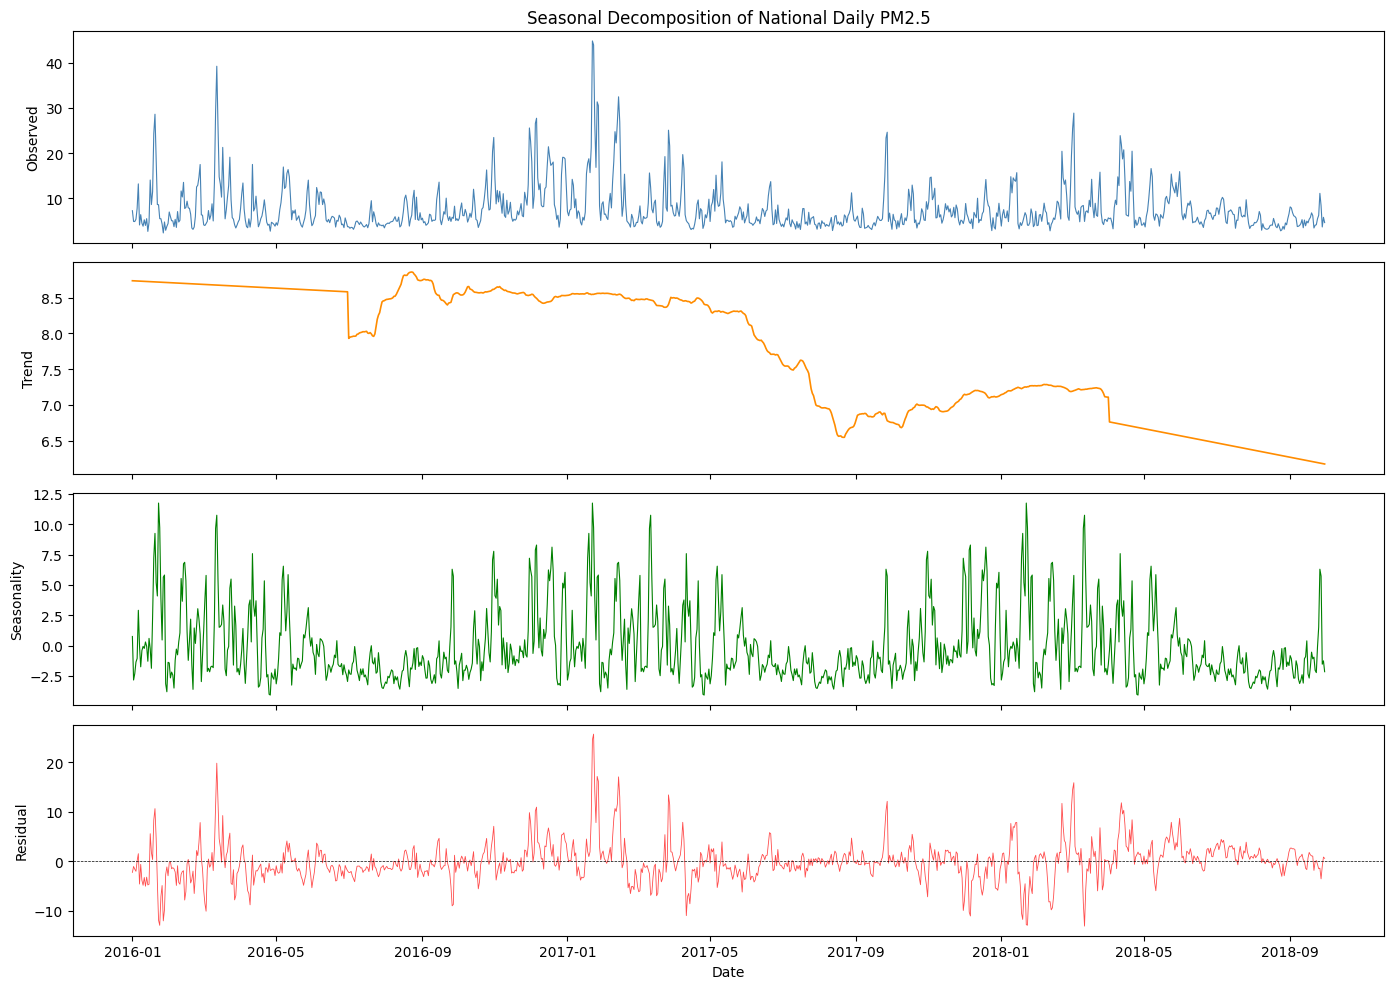

In [30]:
# Use the national daily series
national_series = national.set_index('date')['pm25'].copy()
national_series = national_series.interpolate(method='linear')

# Seasonal decomposition (period=365 for annual seasonality)
decomp = seasonal_decompose(national_series, model='additive', period=365, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomp.observed.index, decomp.observed, linewidth=0.8, color='steelblue')
axes[0].set_ylabel('Observed')
axes[0].set_title('Seasonal Decomposition of National Daily PM2.5')
axes[1].plot(decomp.trend.index, decomp.trend, linewidth=1.2, color='darkorange')
axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal.index, decomp.seasonal, linewidth=0.8, color='green')
axes[2].set_ylabel('Seasonality')
axes[3].plot(decomp.resid.index, decomp.resid, linewidth=0.6, color='red', alpha=0.7)
axes[3].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
plt.tight_layout()
plt.savefig('pm25_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

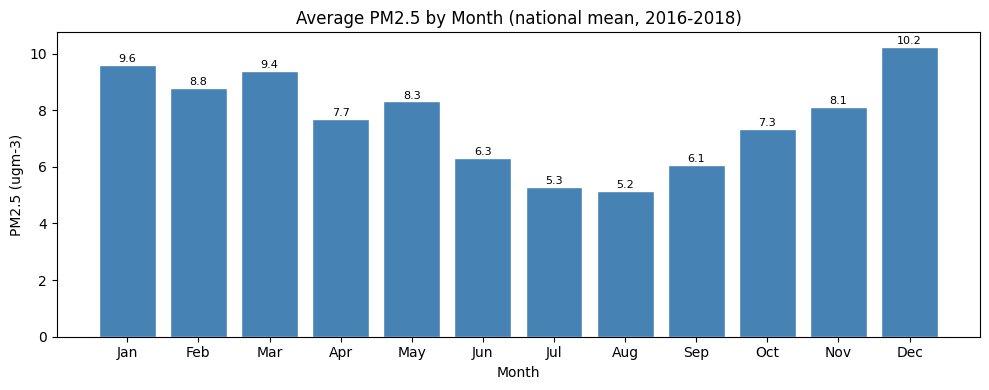

Peak month   : Dec (10.24 ugm-3)
Lowest month : Aug (5.16 ugm-3)


In [ ]:
# Monthly average PM2.5
national_copy = national.copy()
national_copy['month'] = pd.to_datetime(national_copy['date']).dt.month
monthly_avg = national_copy.groupby('month')['pm25'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(monthly_avg.index, monthly_avg.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_title('Average PM2.5 by Month (national mean, 2016-2018)')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.set_xlabel('Month')
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('pm25_monthly_avg.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak month   : {month_names[monthly_avg.idxmax()-1]} ({monthly_avg.max():.2f} ugm-3)')
print(f'Lowest month : {month_names[monthly_avg.idxmin()-1]} ({monthly_avg.min():.2f} ugm-3)')

---
## 2. COVID-19 Impact Analysis
Compares PM2.5 levels during the March-June window across years. The first UK lockdown began 23 March 2020, likely showing a measurable PM2.5 drop.

Loaded 2021-2025 data successfully
PM2.5 during March-June by year (lockdown comparison window):
       mean  median   std
year                     
2016  12.94   11.48  8.43
2017  12.49   11.17  5.97
2018  13.42   11.09  7.61
2021   9.36    7.33  6.60
2022  10.59    8.49  5.93
2023   8.51    7.40  3.66
2024   7.83    6.30  4.92
2025  10.92    7.95  8.35


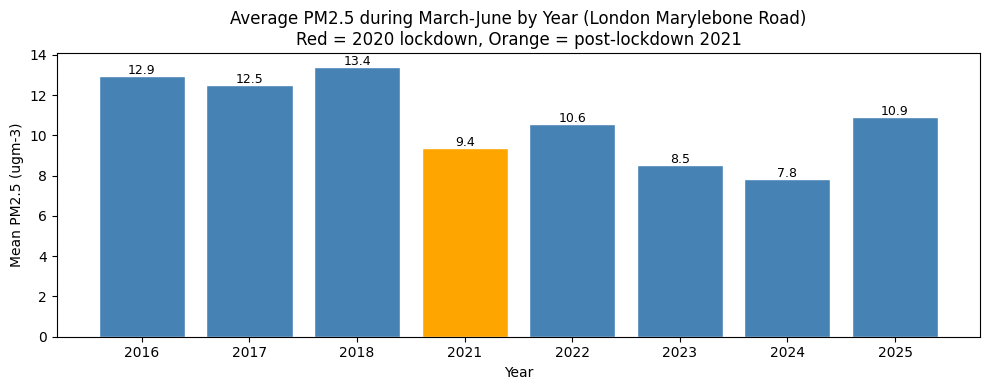

In [6]:
# Use London Marylebone Road (only station with data across all years)
lmbr = df[df['station'] == 'London Marylebone Road'][['date', 'pm25_raw']].copy()

# Try to load 2021-2025 file to extend the comparison
try:
    covid_df = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv',
                           skiprows=11, header=None,
                           names=['date', 'pm25_raw', 'status_raw'])
    covid_df['date'] = pd.to_datetime(covid_df['date'], dayfirst=True, errors='coerce')
    covid_df['pm25_raw'] = pd.to_numeric(covid_df['pm25_raw'], errors='coerce')
    covid_df = covid_df.dropna(subset=['date', 'pm25_raw'])
    lmr_full = pd.concat([lmbr, covid_df[['date', 'pm25_raw']]], ignore_index=True)
    print(f'Loaded 2021-2025 data successfully')
except:
    lmr_full = lmbr.copy()
    print('2021-2025 file not found (using 2016-2018 only)')

lmbr_full = lmr_full.sort_values('date').drop_duplicates('date').set_index('date')

# Compare March-June across years (lockdown window)
lockdown_window = lmbr_full[lmbr_full.index.month.isin([3, 4, 5, 6])].copy()
lockdown_window['year'] = lockdown_window.index.year
yearly_lockdown = lockdown_window.groupby('year')['pm25_raw'].agg(['mean', 'median', 'std']).round(2)

print('PM2.5 during March-June by year (lockdown comparison window):')
print(yearly_lockdown.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue'] * len(yearly_lockdown)
if 2020 in yearly_lockdown.index:
    colors[list(yearly_lockdown.index).index(2020)] = 'red'
if 2021 in yearly_lockdown.index:
    colors[list(yearly_lockdown.index).index(2021)] = 'orange'
bars = ax.bar(yearly_lockdown.index.astype(str), yearly_lockdown['mean'],
              color=colors, edgecolor='white')
ax.set_title('Average PM2.5 during March-June by Year (London Marylebone Road)\nRed = 2020 lockdown, Orange = post-lockdown 2021')
ax.set_ylabel('Mean PM2.5 (ugm-3)')
ax.set_xlabel('Year')
for bar, val in zip(bars, yearly_lockdown['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('pm25_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Station Correlation Heatmap
Shows how similar PM2.5 readings are across the 10 stations. High correlation indicates shared pollution sources or weather; low correlation suggests local factors dominate.

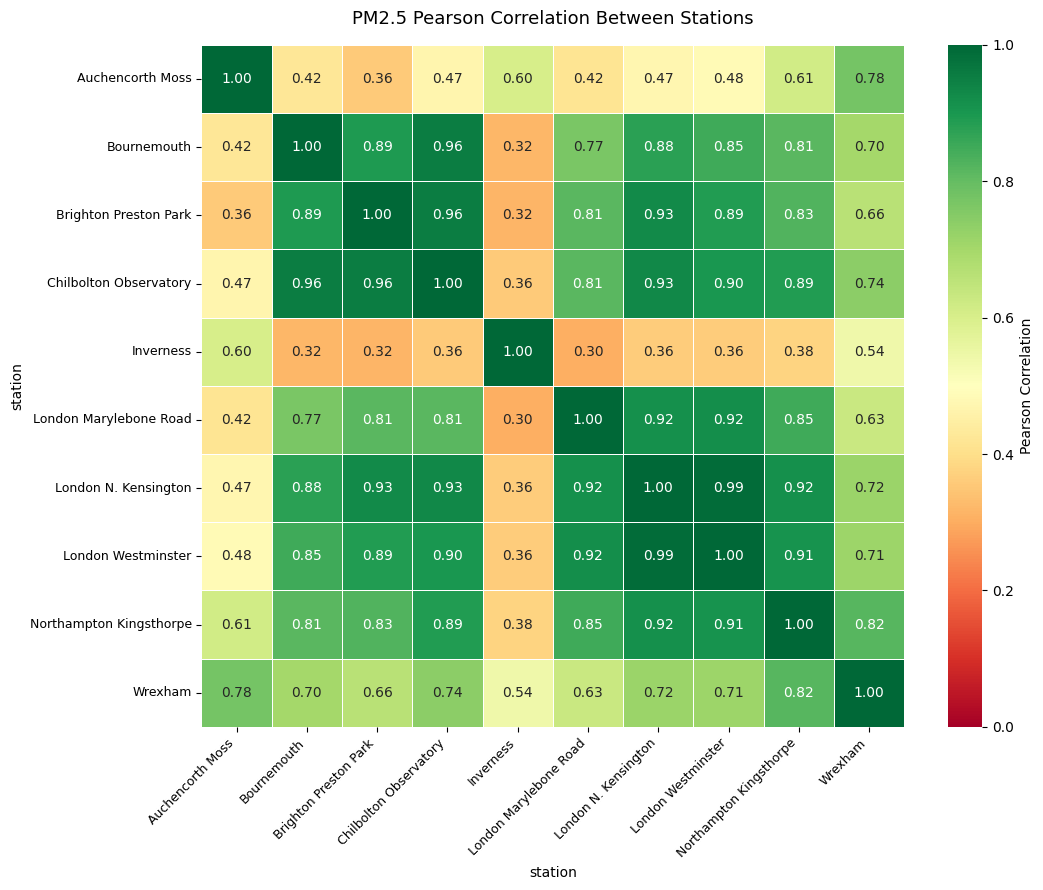

Saved: pm25_station_correlation.png

Top 5 most correlated pairs:
             Station A              Station B  Correlation
    London Westminster   London N. Kensington     0.989747
Chilbolton Observatory            Bournemouth     0.956752
Chilbolton Observatory  Brighton Preston Park     0.955075
  London N. Kensington Chilbolton Observatory     0.933370
  London N. Kensington  Brighton Preston Park     0.926007

Top 5 least correlated pairs:
              Station A               Station B  Correlation
     London Westminster Northampton Kingsthorpe          NaN
     London Westminster                 Wrexham          NaN
Northampton Kingsthorpe Northampton Kingsthorpe          NaN
Northampton Kingsthorpe                 Wrexham          NaN
                Wrexham                 Wrexham          NaN


In [59]:
# Pivot to wide format (one column per station)
wide_corr = df.pivot_table(index='date', columns='station',
                            values='pm25_raw', aggfunc='mean')
corr_matrix = wide_corr.corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('PM2.5 Pearson Correlation Between Stations', fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('pm25_station_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_station_correlation.png')

# Strongest and weakest pairs
corr_pairs_series = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
                         .stack(future_stack=True))
corr_pairs_series.index.names = ['Station A', 'Station B'] # Rename MultiIndex levels
corr_pairs = corr_pairs_series.reset_index()
corr_pairs.columns = ['Station A', 'Station B', 'Correlation']
corr_pairs = corr_pairs.sort_values('Correlation', ascending=False)
print('\nTop 5 most correlated pairs:')
print(corr_pairs.head(5).to_string(index=False))
print('\nTop 5 least correlated pairs:')
print(corr_pairs.tail(5).to_string(index=False))

---
## 4. Feature Engineering
Adds time-based features as inputs for models. These help models learn seasonal and cyclical patterns in PM2.5.

In [58]:
df_feat = df.copy()

# Calendar features
df_feat['day_of_week']  = df_feat['date'].dt.dayofweek
df_feat['day_of_month'] = df_feat['date'].dt.day
df_feat['day_of_year']  = df_feat['date'].dt.dayofyear
df_feat['month']        = df_feat['date'].dt.month
df_feat['year']         = df_feat['date'].dt.year
df_feat['week_of_year'] = df_feat['date'].dt.isocalendar().week.astype(int)
df_feat['quarter']      = df_feat['date'].dt.quarter
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)

# Season
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                    return 'Autumn'

df_feat['season'] = df_feat['month'].apply(get_season)
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
df_feat['season_code'] = df_feat['season'].map(season_map)

# Cyclical encoding (Jan and Dec are close)
df_feat['month_sin']       = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']       = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['day_of_year_sin'] = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['day_of_year_cos'] = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['day_of_week_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
df_feat['day_of_week_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

print('Feature engineering complete. New columns:')
print([c for c in df_feat.columns if c not in df.columns])
print(f'Shape: {df_feat.shape}')
df_feat[['date','station','pm25_raw','season','month_sin','month_cos','is_weekend']].head(5)

Feature engineering complete. New columns:
['day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'season', 'season_code', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']
Shape: (10040, 22)


,date,station,pm25_raw,season,month_sin,month_cos,is_weekend
0,2016-01-01,Auchencorth Moss,2.886000,Winter,0.5,0.866025,0
1,2016-01-01,Bournemouth,5.353000,Winter,0.5,0.866025,0
2,2016-01-01,Brighton Preston Park,8.858000,Winter,0.5,0.866025,0
3,2016-01-01,Chilbolton Observatory,6.619758,Winter,0.5,0.866025,0
4,2016-01-01,Inverness,5.708000,Winter,0.5,0.866025,0


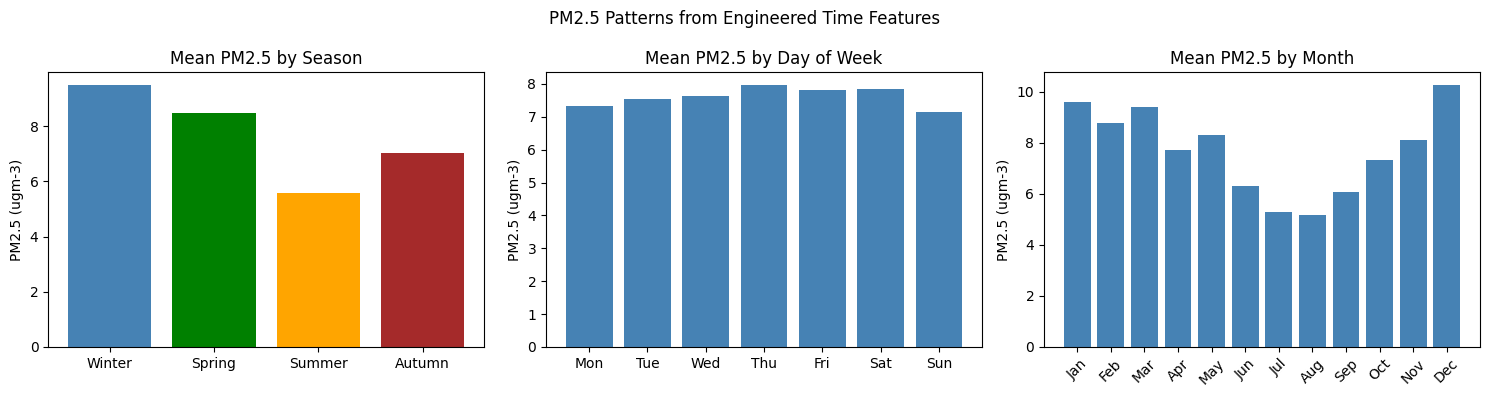

In [61]:
# Visualise patterns from engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

season_pm25 = df_feat.groupby('season')['pm25_raw'].mean().reindex(['Winter','Spring','Summer','Autumn'])
axes[0].bar(season_pm25.index, season_pm25.values, color=['steelblue','green','orange','brown'])
axes[0].set_title('Mean PM2.5 by Season')
axes[0].set_ylabel('PM2.5 (ugm-3)')

dow_pm25 = df_feat.groupby('day_of_week')['pm25_raw'].mean()
axes[1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_pm25.values, color='steelblue')
axes[1].set_title('Mean PM2.5 by Day of Week')
axes[1].set_ylabel('PM2.5 (ugm-3)')

month_pm25 = df_feat.groupby('month')['pm25_raw'].mean()
axes[2].bar(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
            month_pm25.values, color='steelblue')
axes[2].set_title('Mean PM2.5 by Month')
axes[2].set_ylabel('PM2.5 (ugm-3)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('PM2.5 Patterns from Engineered Time Features', fontsize=12)
plt.tight_layout()
plt.savefig('pm25_feature_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

---## 5. Rolling Statistics as Model FeaturesAdds 7-day and 30-day rolling mean and standard deviation per station, plus lag features. These capture short and medium-term trends for model inputs.

In [62]:
df_feat = df_feat.sort_values(['station', 'date']).reset_index(drop=True)

# 7-day rolling stats per station
df_feat['rolling_mean_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_feat['rolling_std_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).std()
)

# 30-day rolling stats per station
df_feat['rolling_mean_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)
df_feat['rolling_std_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).std()
)

# Lag features
df_feat['lag_1d'] = df_feat.groupby('station')['pm25_raw'].shift(1)
df_feat['lag_7d'] = df_feat.groupby('station')['pm25_raw'].shift(7)

print('Rolling statistics and lag features added.')
print(f'Final dataframe shape: {df_feat.shape}')
df_feat[['date','station','pm25_raw','rolling_mean_7d','rolling_std_7d',
          'rolling_mean_30d','lag_1d','lag_7d']].head(10)

Rolling statistics and lag features added.
Final dataframe shape: (10040, 28)


,date,station,pm25_raw,rolling_mean_7d,rolling_std_7d,rolling_mean_30d,lag_1d,lag_7d
0,2016-01-01,Auchencorth Moss,2.886,2.886000,NaN,2.886000,NaN,NaN
1,2016-01-02,Auchencorth Moss,1.120,2.003000,1.248751,2.003000,2.886,NaN
2,2016-01-03,Auchencorth Moss,0.560,1.522000,1.213990,1.522000,1.120,NaN
3,2016-01-04,Auchencorth Moss,1.983,1.637250,1.017666,1.637250,0.560,NaN
4,2016-01-05,Auchencorth Moss,2.372,1.784200,0.940588,1.784200,1.983,NaN
5,2016-01-06,Auchencorth Moss,2.157,1.846333,0.854943,1.846333,2.372,NaN
6,2016-01-07,Auchencorth Moss,0.259,1.619571,0.984405,1.619571,2.157,NaN
7,2016-01-08,Auchencorth Moss,2.330,1.540143,0.882329,1.708375,0.259,2.886
8,2016-01-09,Auchencorth Moss,2.417,1.725429,0.914974,1.787111,2.330,1.120
9,2016-01-10,Auchencorth Moss,1.770,1.898286,0.759130,1.785400,2.417,0.560


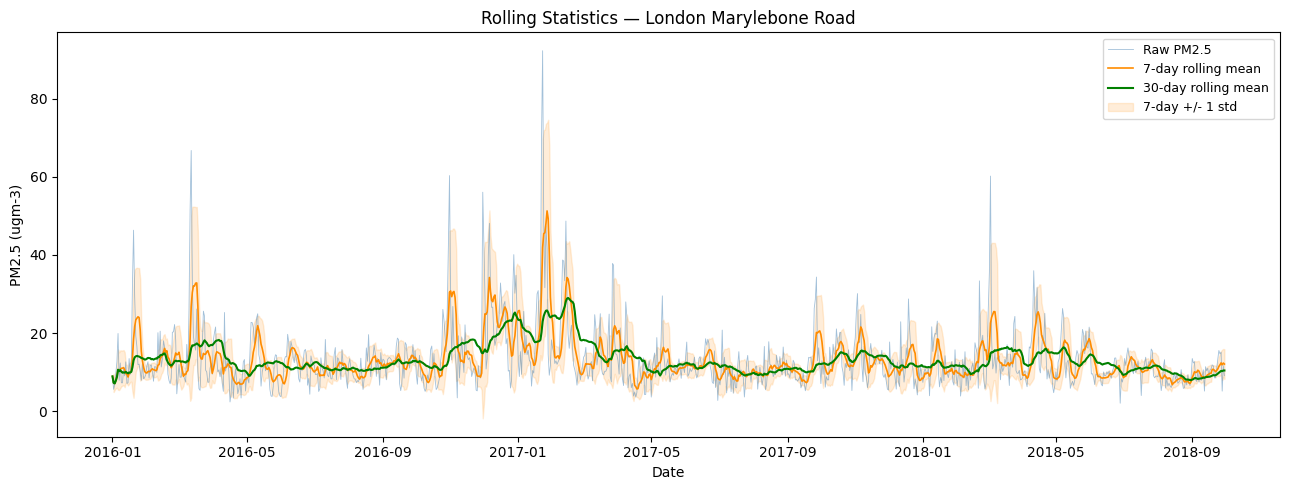

In [63]:
# Visualise rolling stats for London Marylebone Road
station_plot = 'London Marylebone Road'
sub = df_feat[df_feat['station'] == station_plot].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.6, alpha=0.5,
        color='steelblue', label='Raw PM2.5')
ax.plot(sub['date'], sub['rolling_mean_7d'], linewidth=1.2,
        color='darkorange', label='7-day rolling mean')
ax.plot(sub['date'], sub['rolling_mean_30d'], linewidth=1.5,
        color='green', label='30-day rolling mean')
ax.fill_between(sub['date'],
                sub['rolling_mean_7d'] - sub['rolling_std_7d'],
                sub['rolling_mean_7d'] + sub['rolling_std_7d'],
                alpha=0.15, color='darkorange', label='7-day +/- 1 std')
ax.set_title(f'Rolling Statistics — {station_plot}')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# Save final feature-engineered dataset
df_feat.to_csv('pm25_features.csv', index=False)
print(f'Saved: pm25_features.csv')
print(f'Final shape: {df_feat.shape}')
print(f'\nAll columns: {list(df_feat.columns)}')

Saved: pm25_features.csv
Final shape: (10040, 28)

All columns: ['date', 'station', 'pm25_raw', 'pm25_imputed', 'region', 'split', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'season', 'season_code', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_mean_30d', 'rolling_std_30d', 'lag_1d', 'lag_7d']


---
## 5. Rolling Statistics as Model Features
Adds 7-day and 30-day rolling mean and standard deviation per station, plus lag features. These capture short and medium-term trends for model inputs.

In [65]:
df_feat = df_feat.sort_values(['station', 'date']).reset_index(drop=True)

# 7-day rolling stats per station
df_feat['rolling_mean_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_feat['rolling_std_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).std()
)

# 30-day rolling stats per station
df_feat['rolling_mean_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)
df_feat['rolling_std_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).std()
)

# Lag features
df_feat['lag_1d'] = df_feat.groupby('station')['pm25_raw'].shift(1)
df_feat['lag_7d'] = df_feat.groupby('station')['pm25_raw'].shift(7)

print('Rolling statistics and lag features added.')
print(f'Final dataframe shape: {df_feat.shape}')
df_feat[['date','station','pm25_raw','rolling_mean_7d','rolling_std_7d',
          'rolling_mean_30d','lag_1d','lag_7d']].head(10)

Rolling statistics and lag features added.
Final dataframe shape: (10040, 28)


,date,station,pm25_raw,rolling_mean_7d,rolling_std_7d,rolling_mean_30d,lag_1d,lag_7d
0,2016-01-01,Auchencorth Moss,2.886,2.886000,NaN,2.886000,NaN,NaN
1,2016-01-02,Auchencorth Moss,1.120,2.003000,1.248751,2.003000,2.886,NaN
2,2016-01-03,Auchencorth Moss,0.560,1.522000,1.213990,1.522000,1.120,NaN
3,2016-01-04,Auchencorth Moss,1.983,1.637250,1.017666,1.637250,0.560,NaN
4,2016-01-05,Auchencorth Moss,2.372,1.784200,0.940588,1.784200,1.983,NaN
5,2016-01-06,Auchencorth Moss,2.157,1.846333,0.854943,1.846333,2.372,NaN
6,2016-01-07,Auchencorth Moss,0.259,1.619571,0.984405,1.619571,2.157,NaN
7,2016-01-08,Auchencorth Moss,2.330,1.540143,0.882329,1.708375,0.259,2.886
8,2016-01-09,Auchencorth Moss,2.417,1.725429,0.914974,1.787111,2.330,1.120
9,2016-01-10,Auchencorth Moss,1.770,1.898286,0.759130,1.785400,2.417,0.560


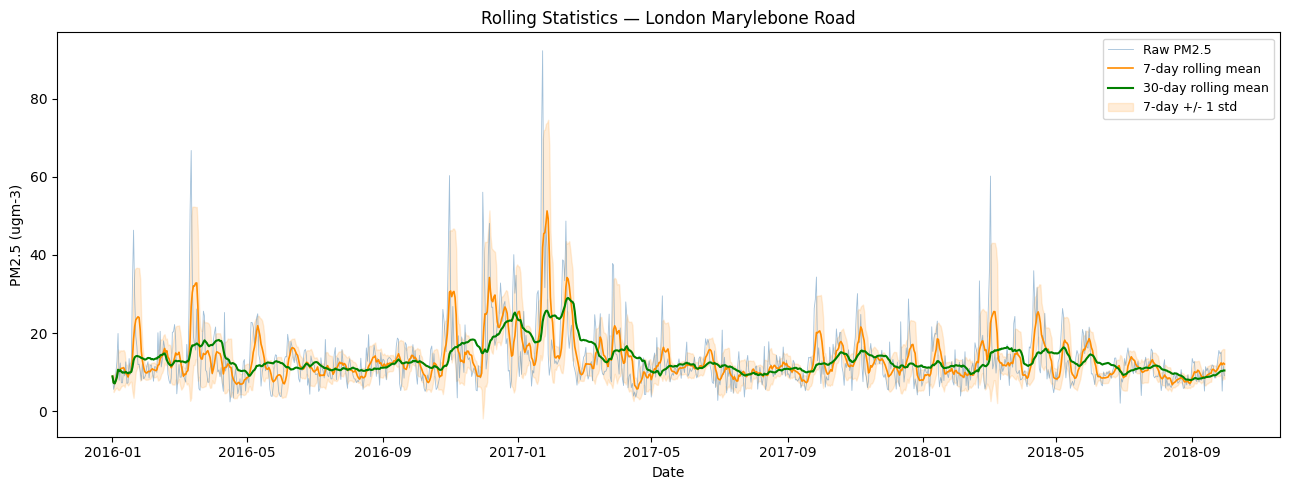

In [ ]:
# Visualise rolling stats for London Marylebone Road
station_plot = 'London Marylebone Road'
sub = df_feat[df_feat['station'] == station_plot].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.6, alpha=0.5,
        color='steelblue', label='Raw PM2.5')
ax.plot(sub['date'], sub['rolling_mean_7d'], linewidth=1.2,
        color='darkorange', label='7-day rolling mean')
ax.plot(sub['date'], sub['rolling_mean_30d'], linewidth=1.5,
        color='green', label='30-day rolling mean')
ax.fill_between(sub['date'],
                sub['rolling_mean_7d'] - sub['rolling_std_7d'],
                sub['rolling_mean_7d'] + sub['rolling_std_7d'],
                alpha=0.15, color='darkorange', label='7-day +/- 1 std')
ax.set_title(f'Rolling Statistics — {station_plot}')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save final feature-engineered dataset
df_feat.to_csv('pm25_features.csv', index=False)
print(f'Saved: pm25_features.csv')
print(f'Final shape: {df_feat.shape}')
print(f'\nAll columns: {list(df_feat.columns)}')


Saved: pm25_features.csv
Final shape: (10040, 28)

All columns: ['date', 'station', 'pm25_raw', 'pm25_imputed', 'region', 'split', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'season', 'season_code', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_mean_30d', 'rolling_std_30d', 'lag_1d', 'lag_7d']


Loaded 2021-2025 data successfully
PM2.5 during March-June by year (lockdown comparison window):
       mean  median   std
year                     
2016  12.94   11.48  8.43
2017  12.49   11.17  5.97
2018  13.42   11.09  7.61
2021   9.36    7.33  6.60
2022  10.59    8.49  5.93
2023   8.51    7.40  3.66
2024   7.83    6.30  4.92
2025  10.92    7.95  8.35


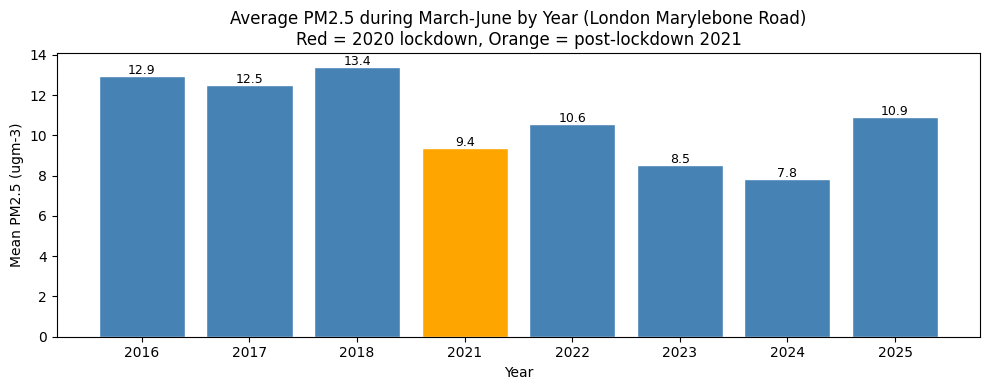

In [7]:
# Use London Marylebone Road (only station with data across all years)
lmbr = df[df['station'] == 'London Marylebone Road'][['date', 'pm25_raw']].copy()

# Try to load 2021-2025 file to extend the comparison
try:
    covid_df = pd.read_csv('/content/AirQualityDataDaily2021_2025.csv',
                           skiprows=11, header=None,
                           names=['date', 'pm25_raw', 'status_raw'])
    covid_df['date'] = pd.to_datetime(covid_df['date'], dayfirst=True, errors='coerce')
    covid_df['pm25_raw'] = pd.to_numeric(covid_df['pm25_raw'], errors='coerce')
    covid_df = covid_df.dropna(subset=['date', 'pm25_raw'])
    lmr_full = pd.concat([lmbr, covid_df[['date', 'pm25_raw']]], ignore_index=True)
    print(f'Loaded 2021-2025 data successfully')
except:
    lmr_full = lmbr.copy()
    print('2021-2025 file not found (using 2016-2018 only)')

lmbr_full = lmr_full.sort_values('date').drop_duplicates('date').set_index('date')

# Compare March-June across years (lockdown window)
lockdown_window = lmbr_full[lmbr_full.index.month.isin([3, 4, 5, 6])].copy()
lockdown_window['year'] = lockdown_window.index.year
yearly_lockdown = lockdown_window.groupby('year')['pm25_raw'].agg(['mean', 'median', 'std']).round(2)

print('PM2.5 during March-June by year (lockdown comparison window):')
print(yearly_lockdown.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue'] * len(yearly_lockdown)
if 2020 in yearly_lockdown.index:
    colors[list(yearly_lockdown.index).index(2020)] = 'red'
if 2021 in yearly_lockdown.index:
    colors[list(yearly_lockdown.index).index(2021)] = 'orange'
bars = ax.bar(yearly_lockdown.index.astype(str), yearly_lockdown['mean'],
              color=colors, edgecolor='white')
ax.set_title('Average PM2.5 during March-June by Year (London Marylebone Road)\nRed = 2020 lockdown, Orange = post-lockdown 2021')
ax.set_ylabel('Mean PM2.5 (ugm-3)')
ax.set_xlabel('Year')
for bar, val in zip(bars, yearly_lockdown['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('pm25_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Station Correlation Heatmap
Shows how similar PM2.5 readings are across the 10 stations. High correlation indicates shared pollution sources or weather; low correlation suggests local factors dominate.

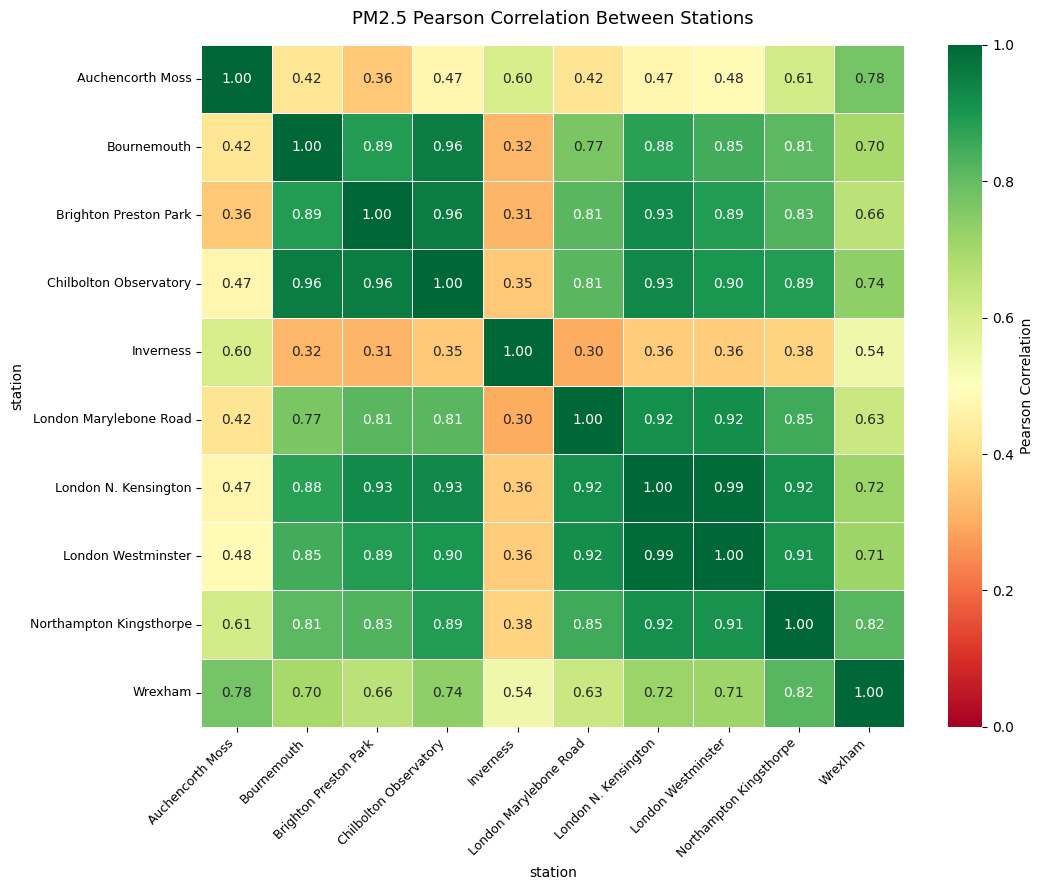

Saved: pm25_station_correlation.png

Top 5 most correlated pairs:
             Station A              Station B  Correlation
    London Westminster   London N. Kensington     0.989743
Chilbolton Observatory            Bournemouth     0.956301
Chilbolton Observatory  Brighton Preston Park     0.955140
  London N. Kensington Chilbolton Observatory     0.933138
  London N. Kensington  Brighton Preston Park     0.926028

Top 5 least correlated pairs:
              Station A               Station B  Correlation
     London Westminster Northampton Kingsthorpe          NaN
     London Westminster                 Wrexham          NaN
Northampton Kingsthorpe Northampton Kingsthorpe          NaN
Northampton Kingsthorpe                 Wrexham          NaN
                Wrexham                 Wrexham          NaN


In [ ]:
# Pivot to wide format (one column per station)
wide_corr = df.pivot_table(index='date', columns='station',
                            values='pm25_raw', aggfunc='mean')
corr_matrix = wide_corr.corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix,
            annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('PM2.5 Pearson Correlation Between Stations', fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('pm25_station_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_station_correlation.png')

# Strongest and weakest pairs
corr_pairs_series = (corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
                         .stack(future_stack=True))
corr_pairs_series.index.names = ['Station A', 'Station B'] # Rename MultiIndex levels
corr_pairs = corr_pairs_series.reset_index()
corr_pairs.columns = ['Station A', 'Station B', 'Correlation']
corr_pairs = corr_pairs.sort_values('Correlation', ascending=False)
print('\nTop 5 most correlated pairs:')
print(corr_pairs.head(5).to_string(index=False))
print('\nTop 5 least correlated pairs:')
print(corr_pairs.tail(5).to_string(index=False))

---
## 4. Feature Engineering
Adds time-based features as inputs for models. These help models learn seasonal and cyclical patterns in PM2.5.

In [66]:
df_feat = df.copy()

# Calendar features
df_feat['day_of_week']  = df_feat['date'].dt.dayofweek
df_feat['day_of_month'] = df_feat['date'].dt.day
df_feat['day_of_year']  = df_feat['date'].dt.dayofyear
df_feat['month']        = df_feat['date'].dt.month
df_feat['year']         = df_feat['date'].dt.year
df_feat['week_of_year'] = df_feat['date'].dt.isocalendar().week.astype(int)
df_feat['quarter']      = df_feat['date'].dt.quarter
df_feat['is_weekend']   = (df_feat['day_of_week'] >= 5).astype(int)

# Season
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                    return 'Autumn'

df_feat['season'] = df_feat['month'].apply(get_season)
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3}
df_feat['season_code'] = df_feat['season'].map(season_map)

# Cyclical encoding (Jan and Dec are close)
df_feat['month_sin']       = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos']       = np.cos(2 * np.pi * df_feat['month'] / 12)
df_feat['day_of_year_sin'] = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['day_of_year_cos'] = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)
df_feat['day_of_week_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
df_feat['day_of_week_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

print('Feature engineering complete. New columns:')
print([c for c in df_feat.columns if c not in df.columns])
print(f'Shape: {df_feat.shape}')
df_feat[['date','station','pm25_raw','season','month_sin','month_cos','is_weekend']].head(5)

Feature engineering complete. New columns:
['day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'season', 'season_code', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos']
Shape: (10040, 22)


,date,station,pm25_raw,season,month_sin,month_cos,is_weekend
0,2016-01-01,Auchencorth Moss,2.886000,Winter,0.5,0.866025,0
1,2016-01-01,Bournemouth,5.353000,Winter,0.5,0.866025,0
2,2016-01-01,Brighton Preston Park,8.858000,Winter,0.5,0.866025,0
3,2016-01-01,Chilbolton Observatory,6.619758,Winter,0.5,0.866025,0
4,2016-01-01,Inverness,5.708000,Winter,0.5,0.866025,0


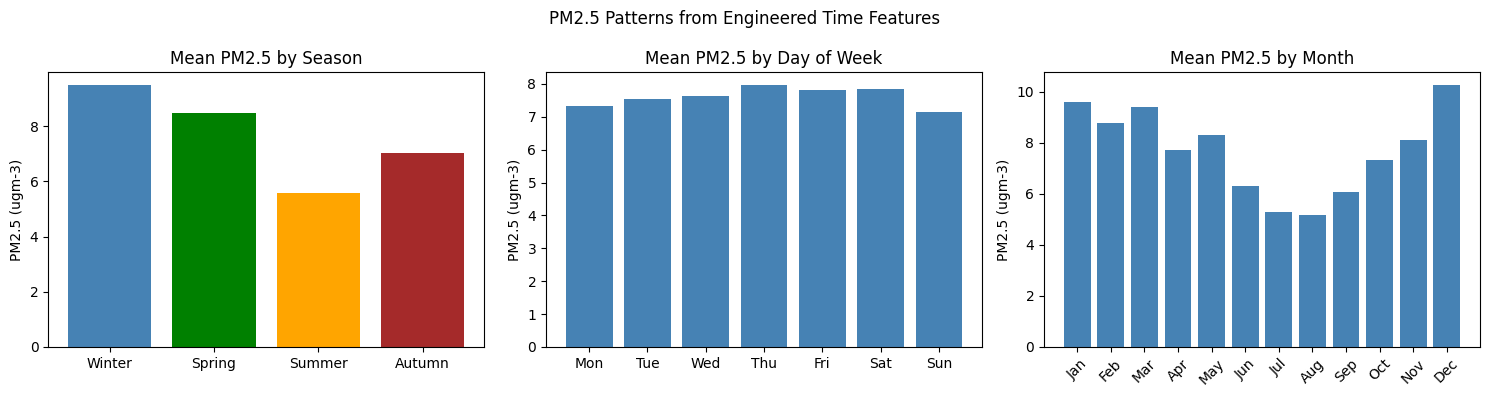

In [67]:
# Visualise patterns from engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

season_pm25 = df_feat.groupby('season')['pm25_raw'].mean().reindex(['Winter','Spring','Summer','Autumn'])
axes[0].bar(season_pm25.index, season_pm25.values, color=['steelblue','green','orange','brown'])
axes[0].set_title('Mean PM2.5 by Season')
axes[0].set_ylabel('PM2.5 (ugm-3)')

dow_pm25 = df_feat.groupby('day_of_week')['pm25_raw'].mean()
axes[1].bar(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], dow_pm25.values, color='steelblue')
axes[1].set_title('Mean PM2.5 by Day of Week')
axes[1].set_ylabel('PM2.5 (ugm-3)')

month_pm25 = df_feat.groupby('month')['pm25_raw'].mean()
axes[2].bar(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
            month_pm25.values, color='steelblue')
axes[2].set_title('Mean PM2.5 by Month')
axes[2].set_ylabel('PM2.5 (ugm-3)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('PM2.5 Patterns from Engineered Time Features', fontsize=12)
plt.tight_layout()
plt.savefig('pm25_feature_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Rolling Statistics as Model Features
Adds 7-day and 30-day rolling mean and standard deviation per station, plus lag features. These capture short and medium-term trends for model inputs.

In [68]:
df_feat = df_feat.sort_values(['station', 'date']).reset_index(drop=True)

# 7-day rolling stats per station
df_feat['rolling_mean_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_feat['rolling_std_7d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(7, min_periods=1).std()
)

# 30-day rolling stats per station
df_feat['rolling_mean_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)
df_feat['rolling_std_30d'] = df_feat.groupby('station')['pm25_raw'].transform(
    lambda x: x.rolling(30, min_periods=1).std()
)

# Lag features
df_feat['lag_1d'] = df_feat.groupby('station')['pm25_raw'].shift(1)
df_feat['lag_7d'] = df_feat.groupby('station')['pm25_raw'].shift(7)

print('Rolling statistics and lag features added.')
print(f'Final dataframe shape: {df_feat.shape}')
df_feat[['date','station','pm25_raw','rolling_mean_7d','rolling_std_7d',
          'rolling_mean_30d','lag_1d','lag_7d']].head(10)

Rolling statistics and lag features added.
Final dataframe shape: (10040, 28)


,date,station,pm25_raw,rolling_mean_7d,rolling_std_7d,rolling_mean_30d,lag_1d,lag_7d
0,2016-01-01,Auchencorth Moss,2.886,2.886000,NaN,2.886000,NaN,NaN
1,2016-01-02,Auchencorth Moss,1.120,2.003000,1.248751,2.003000,2.886,NaN
2,2016-01-03,Auchencorth Moss,0.560,1.522000,1.213990,1.522000,1.120,NaN
3,2016-01-04,Auchencorth Moss,1.983,1.637250,1.017666,1.637250,0.560,NaN
4,2016-01-05,Auchencorth Moss,2.372,1.784200,0.940588,1.784200,1.983,NaN
5,2016-01-06,Auchencorth Moss,2.157,1.846333,0.854943,1.846333,2.372,NaN
6,2016-01-07,Auchencorth Moss,0.259,1.619571,0.984405,1.619571,2.157,NaN
7,2016-01-08,Auchencorth Moss,2.330,1.540143,0.882329,1.708375,0.259,2.886
8,2016-01-09,Auchencorth Moss,2.417,1.725429,0.914974,1.787111,2.330,1.120
9,2016-01-10,Auchencorth Moss,1.770,1.898286,0.759130,1.785400,2.417,0.560


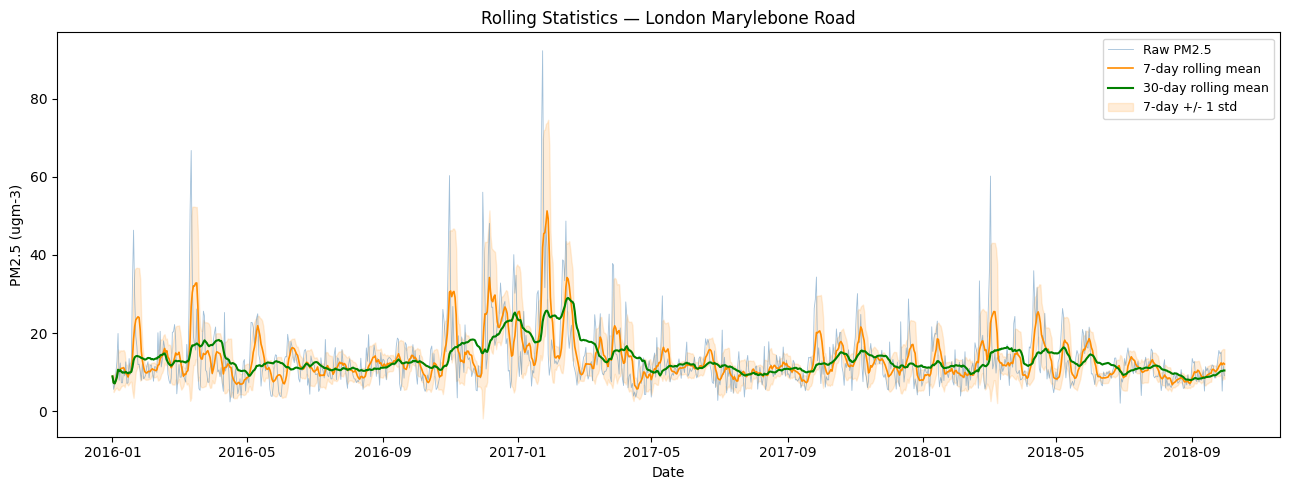

In [ ]:
# Visualise rolling stats for London Marylebone Road
station_plot = 'London Marylebone Road'
sub = df_feat[df_feat['station'] == station_plot].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(sub['date'], sub['pm25_raw'], linewidth=0.6, alpha=0.5,
        color='steelblue', label='Raw PM2.5')
ax.plot(sub['date'], sub['rolling_mean_7d'], linewidth=1.2,
        color='darkorange', label='7-day rolling mean')
ax.plot(sub['date'], sub['rolling_mean_30d'], linewidth=1.5,
        color='green', label='30-day rolling mean')
ax.fill_between(sub['date'],
                sub['rolling_mean_7d'] - sub['rolling_std_7d'],
                sub['rolling_mean_7d'] + sub['rolling_std_7d'],
                alpha=0.15, color='darkorange', label='7-day +/- 1 std')
ax.set_title(f'Rolling Statistics — {station_plot}')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pm25_rolling_stats.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save final feature-engineered dataset
df_feat.to_csv('pm25_features.csv', index=False)
print(f'Saved: pm25_features.csv')
print(f'Final shape: {df_feat.shape}')
print(f'\nAll columns: {list(df_feat.columns)}')

Saved: pm25_features.csv
Final shape: (10040, 28)

All columns: ['date', 'station', 'pm25_raw', 'pm25_imputed', 'region', 'split', 'day_of_week', 'day_of_month', 'day_of_year', 'month', 'year', 'week_of_year', 'quarter', 'is_weekend', 'season', 'season_code', 'month_sin', 'month_cos', 'day_of_year_sin', 'day_of_year_cos', 'day_of_week_sin', 'day_of_week_cos', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_mean_30d', 'rolling_std_30d', 'lag_1d', 'lag_7d']


---

## 6. Autocorrelation (ACF) and Partial Autocorrelation (PACF) Plots

ACF and PACF plots are essential tools in time series analysis to identify the presence and nature of autocorrelation in the data. They help determine the order of AR (autoregressive) and MA (moving average) components for ARIMA models.

*   **ACF (Autocorrelation Function):** Measures the correlation between a time series and its lagged values.
*   **PACF (Partial Autocorrelation Function):** Measures the correlation between a time series and its lagged values, with the influence of intermediate lags removed.

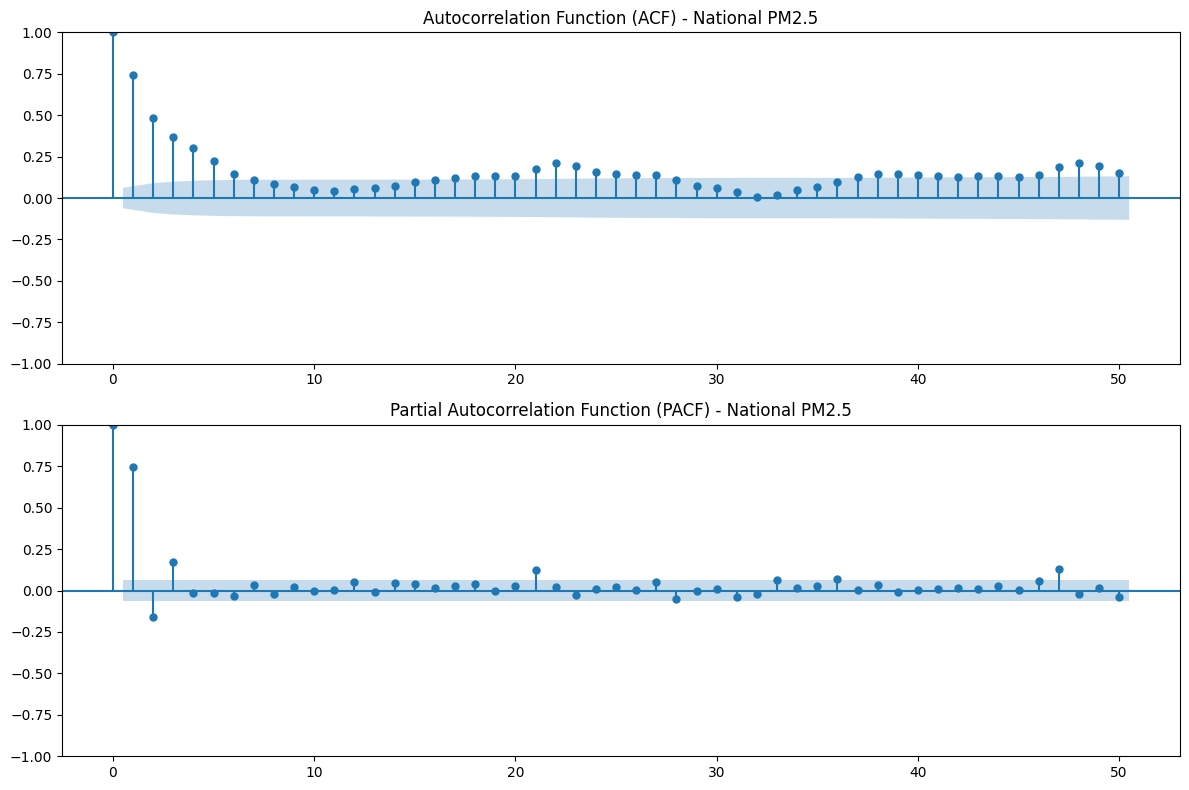

Saved: pm25_acf_pacf.png


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure national_series is clean and has no NaNs for ACF/PACF plots
# (It was already interpolated in the seasonal decomposition section)
national_series_for_acf = national_series.dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(national_series_for_acf, lags=50, ax=axes[0], title='Autocorrelation Function (ACF) - National PM2.5')
plot_pacf(national_series_for_acf, lags=50, ax=axes[1], title='Partial Autocorrelation Function (PACF) - National PM2.5')

plt.tight_layout()
plt.savefig('pm25_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_acf_pacf.png')

---

## 7. Stationarity Test (Augmented Dickey-Fuller - ADF Test)

Stationarity is a key assumption for many time series models. A stationary series has statistical properties (mean, variance, and autocorrelation) that do not change over time. The Augmented Dickey-Fuller (ADF) test is a common statistical test to check for stationarity.

*   **Null Hypothesis (H0):** The time series has a unit root, meaning it is non-stationary.
*   **Alternative Hypothesis (H1):** The time series does not have a unit root, meaning it is stationary.

A low p-value (e.g., < 0.05) suggests that we can reject the null hypothesis and conclude that the series is stationary.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on the national PM2.5 series
result = adfuller(national_series.dropna())

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

if result[1] <= 0.05:
    print('\nConclusion: Reject the null hypothesis (H0). The series is likely stationary.')
else:
    print('\nConclusion: Fail to reject the null hypothesis (H0). The series is likely non-stationary.')

ADF Statistic: -10.296121
p-value: 0.000000
Critical Values:
	1%: -3.437
	5%: -2.864
	10%: -2.568

Conclusion: Reject the null hypothesis (H0). The series is likely stationary.


---

## 8. Monthly Average PM2.5 Heatmap (Across Years)

This heatmap visualizes the average PM2.5 levels for each month across all years in the dataset, providing a clear and concise way to observe annual seasonality patterns and how they might vary from year to year. Darker colors indicate higher average PM2.5, while lighter colors indicate lower levels.

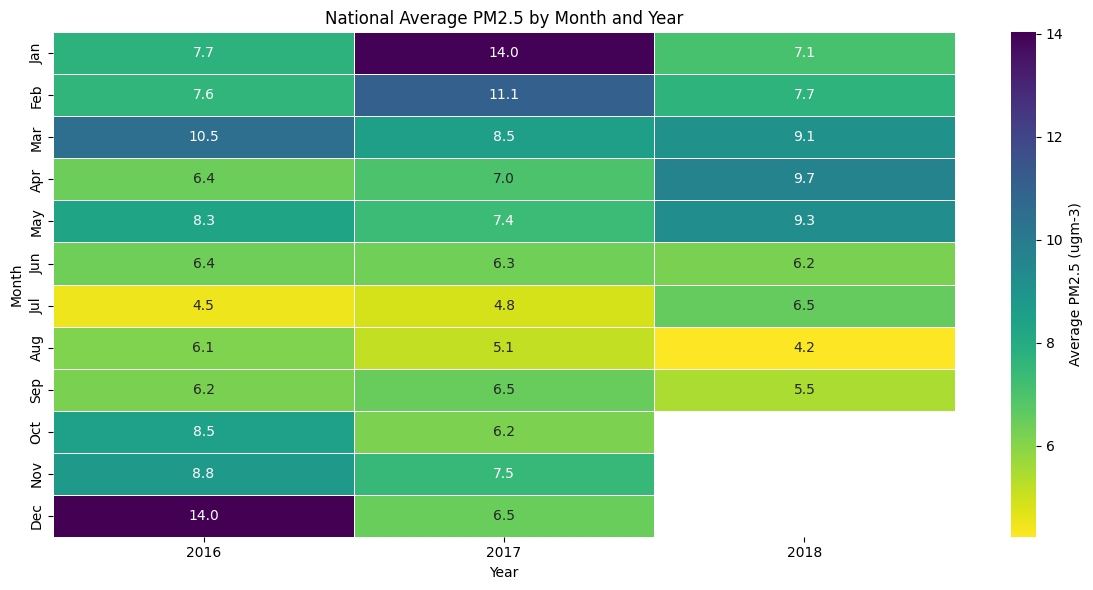

Saved: pm25_monthly_heatmap.png


In [ ]:
national_monthly_avg = national.copy()
national_monthly_avg['month'] = national_monthly_avg['date'].dt.month
national_monthly_avg['year'] = national_monthly_avg['date'].dt.year

# Pivot table for heatmap
heatmap_data = national_monthly_avg.pivot_table(index='month', columns='year', values='pm25')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_data,
            annot=True, fmt='.1f', cmap='viridis_r',
            linewidths=.5, cbar_kws={'label': 'Average PM2.5 (ugm-3)'})
ax.set_title('National Average PM2.5 by Month and Year')
ax.set_xlabel('Year')
ax.set_ylabel('Month')
ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('pm25_monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_monthly_heatmap.png')

---

## 9. Annual Trend Line of National PM2.5

Visualizing the annual trend helps to understand long-term changes in air quality. By plotting a smoothed version of the national PM2.5 data (e.g., using the trend component from seasonal decomposition or a long-term rolling mean), we can observe if PM2.5 levels are generally increasing, decreasing, or remaining stable over the years covered by the dataset.

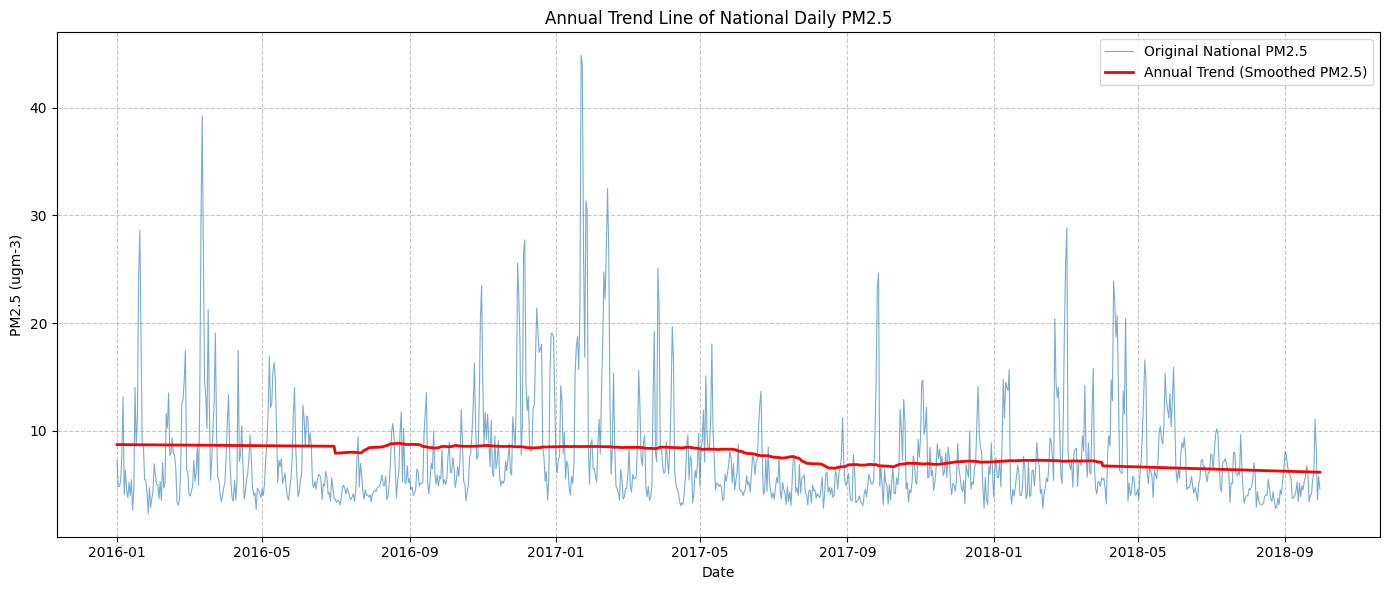

Saved: pm25_annual_trend_line.png


In [69]:
# Use the trend component from the earlier seasonal decomposition
# If `decomp.trend` is not available or has NaNs at ends, fall back to a long rolling mean
trend_series = decomp.trend.dropna() if decomp.trend.isnull().sum() < len(decomp.trend) else national_series.rolling(window=365, center=True).mean().dropna()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(national_series.index, national_series, label='Original National PM2.5', alpha=0.6, linewidth=0.8)
ax.plot(trend_series.index, trend_series, label='Annual Trend (Smoothed PM2.5)', color='red', linewidth=2)
ax.set_title('Annual Trend Line of National Daily PM2.5')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ugm-3)')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('pm25_annual_trend_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pm25_annual_trend_line.png')